# 02 — 4μ iso × iso: loose selection summary

This notebook directly projects the new **6D inclusive merged output**. **No MJJ cut is applied, and |Δφ|≥2 is required**.
Compare k=2 and k=3 separately. SR: both μ-LJs have max pixel≤k. VR: both μ-LJs have max pixel>k. Samples at different k overlap and are not combined as independent experiments.

For 1D closure, **fix the isolation threshold on the other axis at 0.5**. The suggested Δφ=1.5 is a fixed threshold when Δφ is a plane axis;
it does not change the iso×iso event cut |Δφ|≥2 used here. Mixed displacement pass/fail events are excluded from both SR and VR.

Check all 12×12 stored isolation thresholds. Apply no fixed iso<0.5 event cut; scan only the plane thresholds.
This is a **diagnostic** extension of the iso<0.5 WP range in the previous Expanded study, not a scan finer than the stored bins.
Do not select a final WP or retain only points with κ close to 1. `(0.5,0.5)` is the loose comparison point, and `(0.25,0.25)` is the previous comparison point.

The input schema follows [00](00_6D_output_check.ipynb); selections and the 1D layout follow the
[loose reference](Past_reference/ABCD_1D_closure_fixed_events_loose_WP.ipynb).
This notebook runs independently without executing other notebooks or the LPC cache. Use **Restart → Run All**.

The plots follow the correlation, distribution, and κ formats in the [FixedWP reference](Past_reference/ABCD_2mu2e_FixedWP_Plots.ipynb) and the 1D format in the loose reference. Additional diagnostic plots appear in a separate **review** section.

In [1]:
from pathlib import Path
from dataclasses import dataclass
import gc
import sys
import json
from datetime import datetime, timezone

SIDM_DIR = next((p for p in (Path.cwd(), *Path.cwd().parents) if p.name == "sidm"), None)
if SIDM_DIR is None:
    raise RuntimeError("Run this notebook from within the sidm repository.")
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(0, str(SIDM_DIR.parent))
import coffea.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Rectangle
from IPython.display import display

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.spines.top": True,
                     "axes.spines.right": True, "pdf.fonttype": 42})
pd.set_option("display.max_columns", 18)

## 1. Input and scan settings

The inputs are `ABCD_6D_inclusive_eHEM_skimv1_v1_{bkg,data,signal}_merged_samples_v1` in the current folder.
The 18 background and 180 signal files are read one at a time, retaining only small 2D projections. Signal samples from both decay topologies are projected onto the current reconstructed topology, and the yields and metrics are calculated separately for each physical hypothesis. Only the reference shape in the 2D distribution sums the stored weights of all 180 signals and normalizes the result to unit area; this combined shape is not used as a physical signal hypothesis or in the DATA gate.
The stored weighted sumw/sumw2 are used directly, without multiplying by lumi/xsec again.
If `SIGNAL_SCALE` is changed, sumw2 is scaled by the square of the factor.

The selection details in the production metadata are `<not found>`, and the histogram collection is an empty list, so the full set of original production cuts has not been independently verified.
This analysis assumes the frozen typed-LJ pair and baseline of the reference. `SIGNAL_NORMALIZATION_VERIFIED=False` records the status of the normalization evidence; it is not an option to disable blinding.


In [2]:
CAMPAIGN = "ABCD_6D_inclusive_eHEM_skimv1_v1"
INPUT_BASE = SIDM_DIR / "studies/ABCD_plane_summary"
TOPOLOGY = '4mu'
TOPOLOGY_LABEL = '4μ'
X_LABEL, Y_LABEL = ('Leading μ-LJ isolation', 'Subleading μ-LJ isolation')
PIXEL_WPS = (2, 3)
VARS = ("iso0", "iso1", "disp0", "disp1", "abs_dphi", "ljlj_mass")
EDGES = {
    "iso": np.array([0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5]),
    "pixel": np.arange(-.5, 12, 1, dtype=float),
    "lost": np.arange(-.5, 10, 1, dtype=float),
    "abs_dphi": np.array([0, .5, 1, 1.5, 2, 2.2, 2.4, 2.6, 2.7, 2.8, 2.9, 3, 3.05, 3.1, np.pi]),
    "ljlj_mass": np.array([0, 50, 100, 150, 200, 300, 400, 600, 800, 1000, 1500, 2500], float),
}
ISO_CUTS = EDGES["iso"][1:]
DISPLAY_WP = (.5, .5)  # Loose comparison point; not an optimized or final WP.
DISPLAY_PROFILE = "pixel2"
ONE_D_FIXED = (.5,)  # Fix only the isolation threshold on the other axis in the 1D scan.
CLOSURE_YLIM = (0,2)  # Show all finite κ values and both ends of their error bars. A fixed range can be specified.
MIN_NEFF = 10.
MAX_SIGNAL_FRACTION = .10
SIGNAL_REFERENCES = {
    "2mu2e": {"prompt": "2Mu2E_1000GeV_0p25GeV_0p002mm", "displaced": "2Mu2E_1000GeV_0p25GeV_0p2mm"},
    "4mu": {"prompt": "4Mu_1000GeV_0p25GeV_0p002mm", "displaced": "4Mu_1000GeV_0p25GeV_0p2mm"},
}
SIGNAL_SCALE = {}
SIGNAL_NORMALIZATION_VERIFIED = False
LOAD_ALL_SIGNALS = True
BACKGROUND_COLORS = {"QCD": "#832db6", "DY": "#b9ac70", "TTJets": "#3f90da", "Diboson": "#717581"}
TARGETS = (("mc_SR", "MC SR"), ("mc_VR", "MC VR"), ("data_VR", "DATA VR"))
SAVE_FIGURES = False
EXPORT_TABLES = False
OUTPUT_DIR = INPUT_BASE / (TOPOLOGY + "_iso_iso_6D_summary")
FIGURE_DIR = OUTPUT_DIR / "figures"
# Save additional review figures as PNG/PDF when run.
SAVE_REVIEW_FIGURES = True
REVIEW_DIR = INPUT_BASE / "Plot_style_review"
REVIEW_ISO_MAX = 1.0  # Display range for the ≤2/≤3 comparison; retain the full scan.


## 2. Calculation conventions and input helpers

- A=iso0 pass/iso1 pass, B=fail/pass, C=pass/fail, D=fail/fail. Isolation passes when `< threshold`.
- All yields, κ values, and signal metrics include underflow/overflow on both plane axes and the unselected axes. The inclusive mass selection also includes underflow.
- Prediction P=BC/D, κ=A/P, and effective count Neff=sumw²/sumw2. The prediction is undefined if B/C/D is nonpositive, and κ is undefined if A is nonpositive.
- Uncertainties use first-order propagation of the stored sumw2. Defined uncertainties are shown even at low statistics, but should not be interpreted as exact low-statistics intervals or significances.
- Neff<10 is a diagnostic flag, not a criterion for removing WPs. Negative MC weights are not clipped in numerical calculations.
- Signal leakage=S_BCD/S_ABCD, and efficiency=S_A/inclusive signal in the corresponding reconstructed topology. This is not an efficiency relative to generated events.
- The B in S/B and prediction inflation always refers to MC with the same selection. Prompt and displaced signals are separate hypotheses.


In [3]:
@dataclass
class Plane:
    """Iso–iso sumw and sumw2, including flow bins, and edges for both axes."""
    w: np.ndarray
    v: np.ndarray
    ex: np.ndarray
    ey: np.ndarray


def _axis_edges(variable):
    if variable in ("iso0", "iso1"):
        return EDGES["iso"]
    if variable in ("disp0", "disp1"):
        return EDGES["lost" if TOPOLOGY == "2mu2e" and variable == "disp1" else "pixel"]
    return EDGES[variable]


def _split(edges, threshold):
    locations = np.flatnonzero(np.isclose(edges, float(threshold), rtol=0, atol=1e-12))
    if len(locations) != 1:
        raise ValueError(f"Threshold is not a stored bin edge: {threshold}")
    return int(locations[0]) + 1


def make_profiles():
    return [dict(profile=f"pixel{pixel:g}", mass_min=None, dphi_min=2., pixel_max=float(pixel))
            for pixel in PIXEL_WPS]


def _source_paths(source):
    directory = INPUT_BASE / f"{CAMPAIGN}_{source}_merged_samples_v1"
    paths = sorted(directory.glob("*.coffea"))
    expected = {"bkg": 18, "data": 68, "signal": 180}[source]
    if len(paths) != expected or any(path.stat().st_size <= 0 for path in paths):
        raise RuntimeError(f"Input file count/size mismatch: {source}; {len(paths)}/{expected}; {directory}")
    return paths


def _background_group(sample):
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample == "TTJets":
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    raise ValueError(f"Unclassified background: {sample}")


def _inventory_row(path, source, group, loaded=True, scale=1.):
    return dict(source=source, sample=path.stem, group=group, file=str(path),
                bytes=path.stat().st_size, loaded=loaded, scale=scale,
                metadata_file=path.with_suffix(".meta.yaml").is_file())


def _load_cube(path, source):
    """Check only the common schema for DATA as well. Apply numerical checks to the selected slice."""
    payload = coffea.util.load(path)
    if not isinstance(payload, dict) or set(payload.get("out", {})) != {path.stem}:
        raise ValueError(f"Sample identity mismatch: {path}")
    out = payload["out"][path.stem]
    expected = {f"abcd6d_{t}" for t in ("2mu2e", "4mu")} | {
        f"abcd6d_ref_{t}_{pair}" for t in ("2mu2e", "4mu")
        for pair in ("iso0_vs_iso1", "iso0_vs_abs_dphi", "disp0_vs_disp1")}
    if set(out["hists"]) != expected:
        raise ValueError(f"6D campaign histogram key mismatch: {path}")
    metadata = out["metadata"]
    if set(metadata["is_data"]) != {source == "data"}:
        raise ValueError(f"is_data metadata mismatch: {path}")
    if set(metadata["unweighted_hist"]) != {False}:
        raise ValueError(f"A weighted histogram is required: {path}")
    if {str(value) for value in metadata["year"]} != {"2018"}:
        raise ValueError(f"year metadata mismatch: {path}")
    if any(h.storage_type.__name__ != "Weight" for h in out["hists"].values()):
        raise ValueError(f"Weight storage mismatch: {path}")
    histogram = out["hists"][f"abcd6d_{TOPOLOGY}"]
    if tuple(a.name for a in histogram.axes) != ("channel",) + tuple(VARS):
        raise ValueError(f"6D axis order mismatch: {path}")
    axis = histogram.axes["channel"]
    channel = f"abcd6d_inclusive_{TOPOLOGY}_dxySpread_cosAlpha_mu_veto_eHEM"
    if (not axis.traits.discrete or axis.traits.underflow or axis.traits.overflow
            or list(axis) != [channel]):
        raise ValueError(f"Topology channel mismatch: {path}")
    for variable in VARS:
        axis, edges = histogram.axes[variable], _axis_edges(variable)
        if not (axis.traits.underflow and axis.traits.overflow):
            raise ValueError(f"Missing flow bins: {path}/{variable}")
        if np.shape(axis.edges) != np.shape(edges) or not np.allclose(
                axis.edges, edges, rtol=0, atol=1e-12):
            raise ValueError(f"Frozen bin edge mismatch: {path}/{variable}")
    values, variances = histogram.values(flow=True), histogram.variances(flow=True)
    shape = (1,) + tuple(len(_axis_edges(variable)) + 1 for variable in VARS)
    if variances is None or values.shape != shape or variances.shape != shape:
        raise ValueError(f"sumw2/shape mismatch: {path}")
    # The ndarray view retains the histogram storage, allowing the payload for the other topology to be released.
    return values[0], variances[0]


def _validate_storage(weights, variances):
    if not np.isfinite(weights).all() or not np.isfinite(variances).all():
        raise ValueError("The selected histogram contains nonfinite values.")
    if np.any(variances < 0):
        raise ValueError("The selected histogram contains negative sumw2 values.")


def _projection(weights, variances, profile, context):
    if context not in {"SR", "VR"}:
        raise ValueError(context)
    pixel_edge = profile["pixel_max"] + .5
    pixel_split = _split(_axis_edges("disp0"), pixel_edge)
    if TOPOLOGY == "2mu2e":
        second_split = _split(_axis_edges("disp1"), .5)  # lost hits >= 1
        second = slice(second_split, None) if context == "SR" else slice(None, second_split)
    else:
        second_split = _split(_axis_edges("disp1"), pixel_edge)
        second = slice(None, second_split) if context == "SR" else slice(second_split, None)
    first = slice(None, pixel_split) if context == "SR" else slice(pixel_split, None)
    dphi = slice(_split(_axis_edges("abs_dphi"), profile["dphi_min"]), None)
    mass = (slice(None) if profile["mass_min"] is None else
            slice(_split(_axis_edges("ljlj_mass"), profile["mass_min"]), None))
    selected = (slice(None), slice(None), first, second, dphi, mass)
    w, v = weights[selected], variances[selected]
    _validate_storage(w, v)
    # In both SR and VR, combine the two displacement requirements with AND.
    return Plane(w.sum(axis=(2, 3, 4, 5)), v.sum(axis=(2, 3, 4, 5)),
                 np.asarray(EDGES["iso"]), np.asarray(EDGES["iso"]))


def _add_plane(planes, key, plane):
    if key not in planes:
        planes[key] = Plane(plane.w.copy(), plane.v.copy(), plane.ex.copy(), plane.ey.copy())
    else:
        target = planes[key]
        if not np.array_equal(target.ex, plane.ex) or not np.array_equal(target.ey, plane.ey):
            raise ValueError("Planes being summed have different binning.")
        target.w += plane.w
        target.v += plane.v


def load_mc(profiles):
    """Retain only 2D projections: per-component and total backgrounds, and per-hypothesis signals."""
    planes, inventory_rows, signal_inclusive = {}, [], {}
    references = set(SIGNAL_REFERENCES[TOPOLOGY].values())
    signal_paths = _source_paths("signal")
    if not references <= {path.stem for path in signal_paths}:
        raise RuntimeError("Required prompt/displaced reference signals are missing.")
    if not LOAD_ALL_SIGNALS:
        signal_paths = [path for path in signal_paths if path.stem in references]
    paths = [("bkg", path) for path in _source_paths("bkg")] + [
        ("signal", path) for path in signal_paths]
    for index, (source, path) in enumerate(paths, 1):
        weights, variances = _load_cube(path, source)
        _validate_storage(weights, variances)
        group = _background_group(path.stem) if source == "bkg" else path.stem
        scale = float(SIGNAL_SCALE.get(path.stem, 1.)) if source == "signal" else 1.
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError(f"A finite positive signal scale is required: {path.stem}")
        if source == "signal":
            signal_inclusive[path.stem] = float(weights.sum()) * scale
        for profile in profiles:
            for context in ("SR", "VR"):
                plane = _projection(weights, variances, profile, context)
                if scale != 1.:
                    plane.w *= scale
                    plane.v *= scale**2
                _add_plane(planes, (group, profile["profile"], context), plane)
                if source == "bkg":
                    _add_plane(planes, ("BKG", profile["profile"], context), plane)
        inventory_rows.append(_inventory_row(path, source, group, scale=scale))
        del weights, variances
        gc.collect()
        if index % 20 == 0 or index == len(paths):
            print(f"MC loading: {index}/{len(paths)}")
    return planes, [path.stem for path in signal_paths], pd.DataFrame(inventory_rows), signal_inclusive


def _quadrants(plane, tx, ty):
    ix, iy = _split(plane.ex, tx), _split(plane.ey, ty)
    slices = {"A": (slice(None, ix), slice(None, iy)),
              "B": (slice(ix, None), slice(None, iy)),
              "C": (slice(None, ix), slice(iy, None)),
              "D": (slice(ix, None), slice(iy, None))}
    _validate_storage(plane.w, plane.v)
    result = {}
    for region, index in slices.items():
        value, variance = float(plane.w[index].sum()), float(plane.v[index].sum())
        neff = value**2 / variance if variance > 0 else 0. if value == 0 else np.nan
        result[region] = dict(value=value, variance=variance, neff=neff)
    return result


def _empty_metrics(tx, ty, status):
    result = dict(threshold_x=float(tx), threshold_y=float(ty), pred=np.nan,
                  pred_error=np.nan, kappa=np.nan, kappa_error=np.nan, pull=np.nan,
                  min_neff=np.nan, min_sideband_neff=np.nan, low_stat=np.nan,
                  status=status, kappa_status=status)
    for region in "ABCD":
        result.update({region: np.nan, "var_" + region: np.nan,
                       "neff_" + region: np.nan, region + "_error": np.nan})
    return result


def metrics(plane, tx, ty):
    stats = _quadrants(plane, tx, ty)
    result = _empty_metrics(tx, ty, "EMPTY_OR_NONPOSITIVE_SIDEBAND")
    for region, item in stats.items():
        result.update({region: item["value"], "var_" + region: item["variance"],
                       "neff_" + region: item["neff"], region + "_error": np.sqrt(item["variance"])})
    neffs = np.array([stats[r]["neff"] for r in "ABCD"])
    result.update(min_neff=float(np.min(neffs)), min_sideband_neff=float(np.min(neffs[1:])),
                  low_stat=bool(not np.all(np.isfinite(neffs) & (neffs >= MIN_NEFF))))
    a, b, c, d = (stats[r]["value"] for r in "ABCD")
    va, vb, vc, vd = (stats[r]["variance"] for r in "ABCD")
    if not all(np.isfinite(value) and value > 0 for value in (b, c, d)):
        return result
    pred = b * c / d
    vp = (c / d)**2 * vb + (b / d)**2 * vc + (b * c / d**2)**2 * vd
    if not np.isfinite(pred) or pred <= 0 or not np.isfinite(vp):
        result.update(status="UNDEFINED_PREDICTION", kappa_status="UNDEFINED_PREDICTION")
        return result
    result.update(pred=pred, pred_error=np.sqrt(vp),
                  status="OK" if np.all(np.isfinite(neffs[1:]) & (neffs[1:] >= MIN_NEFF))
                  else "LOW_STAT_SIDEBAND")
    if a <= 0:
        result["kappa_status"] = "EMPTY_OR_NONPOSITIVE_A"
        return result
    kappa_variance = va / pred**2 + a**2 * vp / pred**4
    result.update(kappa=a / pred, kappa_error=np.sqrt(kappa_variance),
                  kappa_status="LOW_STAT" if result["low_stat"] else "OK",
                  pull=(a - pred) / np.sqrt(va + vp) if va + vp > 0 else np.nan)
    return result


def signal_metrics(signalplane, bkgplane, tx, ty, inclusive):
    signal, background = _quadrants(signalplane, tx, ty), _quadrants(bkgplane, tx, ty)
    result = dict(leakage=np.nan, leakage_error=np.nan, eff_A=np.nan, s_over_b=np.nan,
                  prediction_inflation=np.nan, signal_total=np.nan, signal_status="UNSUPPORTED")
    for region, item in signal.items():
        result.update({"signal_" + region: item["value"],
                       "signal_var_" + region: item["variance"], "signal_neff_" + region: item["neff"]})
    values = np.array([signal[r]["value"] for r in "ABCD"])
    if not np.isfinite(values).all() or np.any(values < 0):
        result["signal_status"] = "NEGATIVE_OR_UNDEFINED_SIGNAL"
        return result
    a, sb, sc, sd = values
    total = float(values.sum())
    result["signal_total"] = total
    if total <= 0:
        result["signal_status"] = "EMPTY_SIGNAL"
        return result
    leak, va = sb + sc + sd, signal["A"]["variance"]
    vl = sum(signal[r]["variance"] for r in "BCD")
    result.update(leakage=leak / total, leakage_error=np.sqrt((a*a*vl + leak*leak*va) / total**4),
                  eff_A=a / inclusive if np.isfinite(inclusive) and inclusive > 0 else np.nan,
                  signal_status="OK" if all(signal[r]["neff"] >= MIN_NEFF for r in "ABCD") else "LOW_STAT")
    if not np.isfinite(inclusive) or inclusive <= 0:
        result["signal_status"] = "NONPOSITIVE_OR_UNDEFINED_INCLUSIVE"
    ba, b, c, d = (background[r]["value"] for r in "ABCD")
    if ba > 0:
        result["s_over_b"] = a / ba
    if all(np.isfinite(value) and value > 0 for value in (b, c, d)):
        pred = b * c / d
        if np.isfinite(pred) and pred > 0:
            result["prediction_inflation"] = ((b + sb) * (c + sc) / (d + sd)) / pred - 1
    return result


def _signal_gate(background, signals):
    reasons, fractions = [], []
    for role in ("prompt", "displaced"):
        for context, regions in (("SR", "BCD"), ("VR", "ABCD")):
            for region in regions:
                b = background[context][region]
                s = signals[(role, context)]["signal_" + region]
                label = f"{role}_{context}_{region}"
                if not np.isfinite(b) or b <= 0:
                    reasons.append(label + ":nonpositive_or_undefined_background")
                elif not np.isfinite(s) or s < 0:
                    reasons.append(label + ":negative_or_undefined_signal")
                else:
                    fraction = s / (s + b)
                    fractions.append((fraction, label))
                    if fraction > MAX_SIGNAL_FRACTION and not np.isclose(
                            fraction, MAX_SIGNAL_FRACTION, rtol=0, atol=2*np.finfo(float).eps):
                        reasons.append(label + ":signal_fraction_exceeds_limit")
    return dict(gate_passed=not reasons, gate_reason="; ".join(reasons),
                gate_max_fraction=max(fractions)[0] if fractions else np.nan,
                gate_worst=max(fractions)[1] if fractions else "UNDEFINED")


def make_mc_scan(planes, profiles, signal_inclusive):
    if not 0 < MAX_SIGNAL_FRACTION < 1:
        raise ValueError("MAX_SIGNAL_FRACTION must be between 0 and 1.")
    rows = []
    for profile in profiles:
        name = profile["profile"]
        for tx in ISO_CUTS:
            for ty in ISO_CUTS:
                row = dict(profile, tx=float(tx), ty=float(ty))
                background, signals = {}, {}
                for context in ("SR", "VR"):
                    bkg = planes[("BKG", name, context)]
                    background[context] = metrics(bkg, tx, ty)
                    row.update({f"mc_{context}_{key}": value for key, value in background[context].items()})
                    for role in ("prompt", "displaced"):
                        sample = SIGNAL_REFERENCES[TOPOLOGY][role]
                        result = signal_metrics(planes[(sample, name, context)], bkg,
                                                tx, ty, signal_inclusive[sample])
                        signals[(role, context)] = result
                        row.update({f"{role}_{context}_{key}": value for key, value in result.items()})
                row.update(_signal_gate(background, signals))
                rows.append(row)
    return pd.DataFrame(rows)


def load_data_vr(planes, profiles, scan):
    """Read and sum only the VR with both displacement cuts inverted for profiles with gate-approved points."""
    allowed = set(scan.loc[scan.gate_passed, "profile"])
    selected_profiles = [profile for profile in profiles if profile["profile"] in allowed]
    # Reset previous sums on rerun to prevent double counting or retaining values outside the new gate.
    for key in list(planes):
        if key[0] == "Data":
            del planes[key]
    paths, rows = _source_paths("data"), []
    for index, path in enumerate(paths, 1):
        if selected_profiles:
            weights, variances = _load_cube(path, "data")
            for profile in selected_profiles:
                plane = _projection(weights, variances, profile, "VR")
                _add_plane(planes, ("Data", profile["profile"], "VR"), plane)
            del weights, variances
            gc.collect()
        rows.append(_inventory_row(path, "data", "Data", loaded=bool(selected_profiles)))
        if selected_profiles and (index % 20 == 0 or index == len(paths)):
            print(f"DATA VR loading: {index}/{len(paths)}; allowed: {len(selected_profiles)} profiles")
    return pd.DataFrame(rows)


def evaluate_data_scan(planes, scan):
    data_rows = []
    for row in scan.itertuples(index=False):
        if row.gate_passed:
            key = ("Data", row.profile, "VR")
            if key not in planes:
                raise RuntimeError(f"Missing DATA VR projection for an allowed profile: {row.profile}")
            result = metrics(planes[key], row.tx, row.ty)
        else:
            result = _empty_metrics(row.tx, row.ty, "GATE_FAILED")
        data_rows.append({"data_VR_" + key: value for key, value in result.items()})
    frame = scan.drop(columns=[column for column in scan if column.startswith("data_VR_")]).copy()
    data_frame = pd.DataFrame(data_rows, index=frame.index)
    return pd.concat([frame, data_frame], axis=1)

In [4]:
"""Diagnostic summaries; shared core supplies np, pd, metrics and signal_metrics."""


def add_neighbor_diagnostics(scan):
    """Immediate grid neighbors share events: report changes, never independent z scores."""
    result = scan.copy()
    grid = [float(x) for x in ISO_CUTS]
    targets = ("mc_SR", "mc_VR", "data_VR")
    if not result.index.is_unique:
        raise ValueError("Scan index must be unique")
    for target in targets:
        result[target + "_neighbor_count"] = 0
        result[target + "_max_abs_delta_kappa"] = np.nan
        result[target + "_max_neighbor_kappa_error"] = np.nan
    for _, rows in result.groupby("profile", sort=False):
        lookup = {}
        for index, row in rows.iterrows():
            positions = []
            for value in (row.tx, row.ty):
                match = np.flatnonzero(np.isclose(grid, value, rtol=0, atol=1e-12))
                if len(match) != 1:
                    raise ValueError("Scan threshold is not an exact configured grid edge")
                positions.append(int(match[0]))
            key = tuple(positions)
            if key in lookup:
                raise ValueError("Duplicate WP within an event profile")
            lookup[key] = index
        for (ix, iy), index in lookup.items():
            adjacent = [lookup[key] for key in ((ix-1, iy), (ix+1, iy),
                        (ix, iy-1), (ix, iy+1)) if key in lookup]
            for target in targets:
                if target == "data_VR" and not bool(result.at[index, "gate_passed"]):
                    continue
                valid = [j for j in adjacent
                         if np.isfinite(result.at[j, target + "_kappa"])
                         and (target != "data_VR" or bool(result.at[j, "gate_passed"]))]
                result.at[index, target + "_neighbor_count"] = len(valid)
                if not valid:
                    continue
                center = result.at[index, target + "_kappa"]
                if np.isfinite(center):
                    result.at[index, target + "_max_abs_delta_kappa"] = max(
                        abs(result.at[j, target + "_kappa"] - center) for j in valid)
                errors = [result.at[j, target + "_kappa_error"] for j in valid
                          if np.isfinite(result.at[j, target + "_kappa_error"])]
                if errors:
                    result.at[index, target + "_max_neighbor_kappa_error"] = max(errors)
    return result


def profile_summary(scan):
    """Counts are overlapping scanned settings, not independent closure tests."""
    rows = []
    for profile, group in scan.groupby("profile", sort=False):
        first = group.iloc[0]
        fractions = group.gate_max_fraction.to_numpy(dtype=float)
        finite = fractions[np.isfinite(fractions)]
        row = dict(profile=profile, mass_min=first.mass_min, dphi_min=first.dphi_min,
                   total_points=len(group), expected_points=len(ISO_CUTS)**2,
                   gate_passed=int(group.gate_passed.astype(bool).sum()),
                   gate_failed=int((~group.gate_passed.astype(bool)).sum()),
                   max_gate_fraction=float(finite.max()) if finite.size else np.nan)
        if "pixel_max" in group:
            row["pixel_max"] = first.pixel_max
        for target in ("mc_SR", "mc_VR", "data_VR"):
            valid = np.isfinite(group[target + "_kappa"].to_numpy(dtype=float))
            supported = group[target + "_min_neff"].to_numpy(dtype=float) >= MIN_NEFF
            if target == "data_VR":
                valid &= group.gate_passed.to_numpy(dtype=bool)
            row[target + "_valid_kappa"] = int(valid.sum())
            row[target + "_supported_neff10"] = int((valid & supported).sum())
            row[target + "_invalid_kappa"] = int((~valid).sum())
        rows.append(row)
    return pd.DataFrame(rows)


def correlation_table(planes, profile, allow_data):
    """Bin-center Pearson rho; plane-axis flows excluded, no signed-bin clipping."""
    if not isinstance(allow_data, (bool, np.bool_)):
        raise TypeError("allow_data must be the evaluated display-WP gate boolean")
    rows = []
    for group in ("QCD", "DY", "TTJets", "Diboson", "BKG", "Data"):
        contexts = ("VR",) if group == "Data" else ("SR", "VR")
        if group == "Data" and not allow_data:
            continue
        for context in contexts:
            key = (group, profile, context)
            if key not in planes:
                continue
            plane = planes[key]
            w, v = plane.w[1:-1, 1:-1], plane.v[1:-1, 1:-1]
            row = dict(group=group, profile=profile, context=context, rho=np.nan,
                       neff=np.nan, status="EMPTY_OR_NONPOSITIVE")
            if not (np.isfinite(w).all() and np.isfinite(v).all()) or np.any(v < 0):
                raise ValueError("Correlation requires finite bins and nonnegative sumw2")
            if np.any(w < 0):
                row["status"] = "SIGNED_WEIGHTS_NOT_PROBABILITY"
            elif w.sum() > 0:
                total, variance = float(w.sum()), float(v.sum())
                row["neff"] = total**2 / variance if variance > 0 else np.nan
                x, y = (plane.ex[:-1]+plane.ex[1:])/2, (plane.ey[:-1]+plane.ey[1:])/2
                mx, my = (w*x[:, None]).sum()/total, (w*y[None, :]).sum()/total
                vx = (w*(x[:, None]-mx)**2).sum()/total
                vy = (w*(y[None, :]-my)**2).sum()/total
                covariance = (w*(x[:, None]-mx)*(y[None, :]-my)).sum()/total
                if vx > 0 and vy > 0:
                    row["rho"] = float(covariance/np.sqrt(vx*vy))
                    row["status"] = ("NO_VARIANCE_SUPPORT" if variance <= 0 else
                                     "LOW_STAT" if row["neff"] < MIN_NEFF else "OK")
                else:
                    row["status"] = "ZERO_AXIS_VARIANCE"
            rows.append(row)
    return pd.DataFrame(rows)


def signal_reference_table(planes, profiles, signal_names, signal_inclusive,
                           working_points=((.25, .25), (.30, .25), (.50, .50))):
    """Separate hypotheses at named comparison WPs; never choose or combine models."""
    names = list(signal_names)
    if len(names) != len(set(names)):
        raise ValueError("Duplicate signal sample names")
    if set(names) & {"Data", "BKG", "QCD", "DY", "TTJets", "Diboson"}:
        raise ValueError("Only signal samples may enter signal_reference_table")
    rows = []
    for config in profiles:
        profile = config["profile"] if isinstance(config, dict) else config
        labels = ({key: config[key] for key in ("mass_min", "dphi_min", "pixel_max") if key in config}
                  if isinstance(config, dict) else {})
        for context in ("SR", "VR"):
            bkg = planes[("BKG", profile, context)]
            for sample in names:
                signal = planes[(sample, profile, context)]
                inclusive = signal_inclusive[sample]
                for tx, ty in working_points:
                    for threshold in (tx, ty):
                        if np.count_nonzero(np.isclose(ISO_CUTS, threshold, rtol=0, atol=1e-12)) != 1:
                            raise ValueError("Signal comparison WP is not a stored scan edge")
                    row = dict(sample=sample, topology=TOPOLOGY, profile=profile,
                               context=context, tx=float(tx), ty=float(ty),
                               wp_role="NAMED_COMPARISON_NOT_SELECTED", **labels)
                    row.update(signal_metrics(signal, bkg, tx, ty, inclusive))
                    rows.append(row)
    return pd.DataFrame(rows)


def data_safety_table(scan):
    """Expose the existing two-hypothesis gate; no new DATA access or selection."""
    rows = []
    for source in scan.to_dict("records"):
        keys = ("profile", "mass_min", "dphi_min", "pixel_max", "tx", "ty",
                "gate_passed", "gate_reason", "gate_max_fraction", "gate_worst")
        row = {key: source[key] for key in keys if key in source}
        worst = str(source.get("gate_worst", "")).split("_")
        role, context, region = worst if len(worst) == 3 else (None, None, None)
        reasons = str(source.get("gate_reason", "")).split(";")
        row.update(gate_worst_role=role, gate_worst_context=context,
                   gate_worst_region=region,
                   gate_worst_sample=SIGNAL_REFERENCES[TOPOLOGY].get(role),
                   invalid_region_count=sum("nonpositive_or_undefined_background" in reason
                                            or "negative_or_undefined_signal" in reason
                                            for reason in reasons),
                   gate_scope="PROMPT_AND_DISPLACED_REFERENCES_ONLY",
                   signal_normalization_verified=bool(globals().get(
                       "SIGNAL_NORMALIZATION_VERIFIED", False)),
                   data_access_allowed=bool(source["gate_passed"]),
                   data_kappa_defined=bool(np.isfinite(source.get("data_VR_kappa", np.nan))))
        rows.append(row)
    return pd.DataFrame(rows)

In [5]:
from matplotlib.colors import TwoSlopeNorm


def show_figure(fig, name):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


def folded_plane(plane):
    arrays = []
    for original in (plane.w, plane.v):
        a = original.copy()
        a[1, :] += a[0, :]
        a[-2, :] += a[-1, :]
        a = a[1:-1, :]
        a[:, 1] += a[:, 0]
        a[:, -2] += a[:, -1]
        arrays.append(a[:, 1:-1])
    return arrays


def profile_description(profile):
    row = next(p for p in profiles if p["profile"] == profile)
    mass = "MJJ inclusive" if row["mass_min"] is None else f"MJJ ≥ {row['mass_min']:g} GeV"
    pixel = (f"both μ-LJs: SR pixel ≤ {row['pixel_max']:g}, VR pixel > {row['pixel_max']:g}"
             if TOPOLOGY == "4mu" else "SR: μ pixel ≤ 2, eγ lost ≥ 1; VR: μ pixel > 2, eγ lost < 1")
    return f"{TOPOLOGY_LABEL}: {mass}, |Δφ| ≥ {row['dphi_min']:g}; {pixel}"


def reference_gate(scan, profile, wp=DISPLAY_WP):
    rows = scan.loc[scan.profile.eq(profile) & np.isclose(scan.tx, wp[0]) & np.isclose(scan.ty, wp[1])]
    if len(rows) != 1:
        raise ValueError("The comparison WP must be a unique scan point at stored bin edges.")
    return bool(rows.iloc[0].gate_passed)


def unavailable_panel(ax, text="DATA VR: reference WP gate failed"):
    ax.set_facecolor("#eeeeee")
    ax.text(.5, .5, text, ha="center", va="center", transform=ax.transAxes, wrap=True)
    ax.set_xticks([])
    ax.set_yticks([])


def _iso_base_scan_panel(ax, scan, profile, column, title, vmin=None, vmax=None, cmap="viridis", mark_low_stat=False):
    rows = scan.loc[scan.profile.eq(profile)]
    grid = rows.pivot(index="ty", columns="tx", values=column).reindex(index=ISO_CUTS, columns=ISO_CUTS)
    limits = (dict(norm=TwoSlopeNorm(vmin=vmin, vcenter=1., vmax=vmax))
              if column in {"mc_SR_kappa", "mc_VR_kappa", "data_VR_kappa"}
              else dict(vmin=vmin, vmax=vmax))
    image = ax.imshow(np.ma.masked_invalid(grid.to_numpy(float)), origin="lower", aspect="equal",
                      **limits, cmap=plt.get_cmap(cmap).with_extremes(bad="#eeeeee"))
    indices = np.arange(len(ISO_CUTS))
    ax.set_xticks(indices, [f"{x:g}" for x in ISO_CUTS], rotation=60, fontsize=8)
    ax.set_yticks(indices, [f"{x:g}" for x in ISO_CUTS], fontsize=8)
    ax.set_xlabel(X_LABEL + " threshold")
    ax.set_ylabel(Y_LABEL + " threshold")
    ax.set_title(title, fontsize=11)
    for wp, color in ((DISPLAY_WP, "black"), ((.25, .25), "#d55e00")):
        x = np.flatnonzero(np.isclose(ISO_CUTS, wp[0]))[0]
        y = np.flatnonzero(np.isclose(ISO_CUTS, wp[1]))[0]
        ax.add_patch(Rectangle((x-.45, y-.45), .9, .9, fill=False, edgecolor=color, linewidth=1.5))
    if mark_low_stat:
        prefix = next((p for p in ("mc_SR", "mc_VR", "data_VR") if column.startswith(p)), None)
        if prefix:
            support = rows.pivot(index="ty", columns="tx", values=prefix+"_min_neff").reindex(index=ISO_CUTS, columns=ISO_CUTS)
            yy, xx = np.nonzero(np.isfinite(grid.to_numpy(float)) & (support.to_numpy(float) < MIN_NEFF))
            ax.scatter(xx, yy, marker="x", color="#444444", s=12, linewidths=.6)
    ax.figure.colorbar(image, ax=ax, shrink=.8, extend="both" if vmin is not None and vmax is not None else "neither")




def plot_detailed_maps(scan, profile):
    diagnostics = (("kappa", "κ", 0, 4, "coolwarm"),
                   ("kappa_error", "σ(κ), delta method", 0, 1, "magma"),
                   ("min_neff", "min Neff(A,B,C,D)", 0, 30, "viridis"),
                   ("pull", "(A − BC/D) / σ", -3, 3, "coolwarm"))
    fig, axes = plt.subplots(len(diagnostics), 3, figsize=(15, 18), constrained_layout=True)
    for row, (metric, label, lower, upper, cmap) in enumerate(diagnostics):
        for col, (prefix, title) in enumerate(TARGETS):
            scan_panel(axes[row, col], scan, profile, prefix+"_"+metric, title+": "+label, lower, upper, cmap, metric=="kappa")
    fig.suptitle(profile_description(profile), fontsize=14)
    show_figure(fig, "detailed_maps_"+profile)


def plane_panel(ax, plane, title, normalized=False):
    w, v = folded_plane(plane)
    total = float(w.sum())
    if normalized:
        if total <= 0:
            unavailable_panel(ax, "Nonpositive signal total")
            return
        w = w / total
    positive = w[w > 0]
    if np.any(w < 0):
        scale = max(float(np.max(np.abs(w))), 1e-12)
        norm = SymLogNorm(linthresh=scale*1e-3, vmin=-scale, vmax=scale)
        cmap = "coolwarm"
    elif positive.size:
        norm = LogNorm(vmin=max(float(positive.min()), float(positive.max())*1e-5), vmax=float(positive.max())*(1+1e-12))
        cmap = "viridis"
    else:
        unavailable_panel(ax, "Empty plane")
        return
    image = ax.pcolormesh(plane.ex, plane.ey, w.T, norm=norm, cmap=cmap, shading="flat")
    ax.set_xscale("symlog", linthresh=.5)
    ax.set_yscale("symlog", linthresh=.5)
    ticks = [0, .25, .5, 1, 2, 5]
    ax.set_xticks(ticks, [str(x) for x in ticks])
    ax.set_yticks(ticks, [str(x) for x in ticks])
    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(Y_LABEL)
    ax.axvline(DISPLAY_WP[0], color="red", linestyle="--", linewidth=1)
    ax.axhline(DISPLAY_WP[1], color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title}\nΣw={total:.4g}" if not normalized else title)
    ax.figure.colorbar(image, ax=ax, label="fraction / stored bin" if normalized else "sumw / stored bin", shrink=.8)






def plot_vr_projections(planes, scan, profile):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True)
    allowed = reference_gate(scan, profile)
    for direction, label in enumerate((X_LABEL, Y_LABEL)):
        ax, ratio_ax = axes[:, direction]
        sum_axis = 1-direction
        total_w, total_v = folded_plane(planes[("BKG", profile, "VR")])
        mc, vmc = total_w.sum(axis=sum_axis), total_v.sum(axis=sum_axis)
        edges = EDGES["iso"]
        centers, widths = (edges[:-1]+edges[1:])/2, np.diff(edges)
        baseline = np.zeros(len(centers))
        for group in BACKGROUND_COLORS:
            w, _ = folded_plane(planes[(group, profile, "VR")])
            y = w.sum(axis=sum_axis)
            ax.stairs(baseline+y, edges, baseline=baseline, fill=True, alpha=.75,
                      color=BACKGROUND_COLORS[group], label=group)
            baseline += y
        ax.fill_between(edges, np.r_[mc-np.sqrt(vmc), (mc-np.sqrt(vmc))[-1]],
                        np.r_[mc+np.sqrt(vmc), (mc+np.sqrt(vmc))[-1]], step="post", color="black", alpha=.18, label="MC stat.")
        if allowed:
            wd, vd = folded_plane(planes[("Data", profile, "VR")])
            data, vdata = wd.sum(axis=sum_axis), vd.sum(axis=sum_axis)
            ax.errorbar(centers, data, yerr=np.sqrt(vdata), fmt="o", color="black", markersize=3, label="DATA VR")
            good = mc > 0
            ratio_ax.errorbar(centers[good], data[good]/mc[good], yerr=np.sqrt(vdata[good])/mc[good], fmt="o", color="black", markersize=3)
        else:
            ratio_ax.text(.5, .7, "DATA reference gate failed", transform=ratio_ax.transAxes, ha="center")
        band = np.divide(np.sqrt(vmc), mc, out=np.full_like(mc, np.nan), where=mc>0)
        ratio_ax.fill_between(edges, np.r_[1-band, (1-band)[-1]], np.r_[1+band, (1+band)[-1]], step="post", color="gray", alpha=.3)
        ratio_ax.axhline(1, color="black", linewidth=.8)
        ratio_ax.set_ylim(0, 2)
        ratio_ax.set_ylabel("DATA / MC")
        ratio_ax.set_xlabel(label)
        for panel in (ax, ratio_ax):
            panel.set_xscale("symlog", linthresh=.5)
            panel.set_xlim(0, 5)
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel("sumw / stored bin")
        ax.legend(fontsize=8)
    fig.suptitle(profile_description(profile)+"; VR projections, flow folded")
    show_figure(fig, "vr_projections_"+profile)


def plot_signal_maps(scan, profile):
    panels = (("gate_max_fraction", "max S/(S+B_MC), both hypotheses", 0, .2),
              ("displaced_SR_leakage", "displaced SR leakage S_BCD / S_ABCD", 0, .5),
              ("displaced_SR_eff_A", "displaced SR A / inclusive topology", 0, 1),
              ("prompt_SR_leakage", "prompt SR leakage S_BCD / S_ABCD", 0, 1),
              ("displaced_SR_s_over_b", "displaced SR S_A / MC B_A", 0, 1),
              ("displaced_SR_prediction_inflation", "displaced SR prediction inflation", -.3, .3))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
    for ax, (column, title, lower, upper) in zip(axes.flat, panels):
        scan_panel(ax, scan, profile, column, title, lower, upper, "coolwarm" if "inflation" in column else "viridis")
    fig.suptitle(profile_description(profile)+"; normalization conditional on stored xsec / BR")
    show_figure(fig, "signal_diagnostics_"+profile)


def plot_neighbors(scan, profile):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
    for ax, (prefix, title) in zip(axes, TARGETS):
        scan_panel(ax, scan, profile, prefix+"_max_abs_delta_kappa", title+": max adjacent |Δκ|", 0, 1, "magma")
    fig.suptitle(profile_description(profile)+"; diagnostic only, correlated WPs")
    show_figure(fig, "neighbors_"+profile)

"""FixedWP reference presentation; existing projections and per-WP DATA gates only."""
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize, TwoSlopeNorm
from matplotlib.patches import Rectangle

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
                     "axes.spines.top": True, "axes.spines.right": True, "pdf.fonttype": 42})


def _iso_reference_caption(profile, context=None):
    config = next(p for p in profiles if p["profile"] == profile)
    fixed = f"|Δφ| ≥ {config['dphi_min']:g} · "
    fixed += "M(LJ,LJ) inclusive" if config["mass_min"] is None else f"M(LJ,LJ) ≥ {config['mass_min']:g} GeV"
    if context is None:
        return f"Pixel split k={config['pixel_max']:g} · " + fixed
    if context not in ("SR", "VR"):
        raise ValueError(context)
    pixel = config["pixel_max"]
    if TOPOLOGY == "2mu2e":
        cuts = f"μ pixel ≤ {pixel:g} AND eγ lost ≥ 1" if context == "SR" else f"μ pixel > {pixel:g} AND eγ lost < 1"
    else:
        cuts = f"Both μ-LJs: pixel {'≤' if context == 'SR' else '>'} {pixel:g}"
    return cuts + " · " + fixed


def _iso_reference_corr(plane, tx, ty):
    windows = ("All", "A", "B", "C", "D")
    if plane is None:
        return [dict(window=w, rho=np.nan, neff=np.nan, status="GATE_BLOCKED") for w in windows]
    xx, yy = np.broadcast_arrays(((plane.ex[:-1]+plane.ex[1:])/2)[:, None],
                                 ((plane.ey[:-1]+plane.ey[1:])/2)[None, :])
    xp, yp = xx < tx, yy < ty
    masks = (np.ones(xx.shape, bool), xp & yp, ~xp & yp, xp & ~yp, ~xp & ~yp)
    w, v = plane.w[1:-1, 1:-1], plane.v[1:-1, 1:-1]
    rows = []
    for window, take in zip(windows, masks):
        ww, vv = w[take], v[take]
        row = dict(window=window, rho=np.nan, neff=np.nan, status="EMPTY")
        if not (np.isfinite(ww).all() and np.isfinite(vv).all()) or np.any(vv < 0):
            row["status"] = "INVALID_BIN"
        elif np.any(ww < 0):
            row["status"] = "SIGNED_WEIGHTS_NOT_PROBABILITY"
        elif ww.size and ww.sum() > 0 and vv.sum() > 0:
            total = float(ww.sum())
            row["neff"] = total**2 / float(vv.sum())
            xs, ys = xx[take], yy[take]
            mx, my = np.dot(ww, xs)/total, np.dot(ww, ys)/total
            vx, vy = np.dot(ww, (xs-mx)**2)/total, np.dot(ww, (ys-my)**2)/total
            if vx <= 0 or vy <= 0:
                row["status"] = "NO_SPREAD"
            else:
                rho = float(np.dot(ww, (xs-mx)*(ys-my))/total/np.sqrt(vx*vy))
                if not np.isfinite(rho) or abs(rho) > 1+1e-10:
                    row["status"] = "INVALID_MOMENTS"
                else:
                    row.update(rho=float(np.clip(rho, -1, 1)),
                               status="LOW_STAT" if row["neff"] < MIN_NEFF else "OK")
        rows.append(row)
    return rows


def _iso_reference_corr_figure(table, row_pairs, title, profile, name):
    windows = ("All", "A", "B", "C", "D")
    values = np.full((len(row_pairs), len(windows)), np.nan)
    records = {}
    for i, (group, context, _) in enumerate(row_pairs):
        subset = table.loc[table.group.eq(group) & table.context.eq(context)]
        for j, window in enumerate(windows):
            row = subset.loc[subset.window.eq(window)].iloc[0]
            records[i, j] = row
            values[i, j] = row.rho
    fig, ax = plt.subplots(figsize=(10, 2.05+.78*len(row_pairs)), constrained_layout=True)
    cmap = plt.get_cmap("coolwarm").copy(); cmap.set_bad("0.93")
    mesh = ax.imshow(np.ma.masked_invalid(values), aspect="auto", cmap=cmap, vmin=-1, vmax=1)
    status_labels = {"GATE_BLOCKED": "Gate blocked", "SIGNED_WEIGHTS_NOT_PROBABILITY": "Signed bins",
                     "NO_SPREAD": "No spread", "EMPTY": "Empty"}
    for (i, j), row in records.items():
        if np.isfinite(row.rho):
            label = f"ρ={row.rho:+.3f}\nN_eff={row.neff:.1f}"
            if row.status == "LOW_STAT": label += "\nLOW STAT"
        else:
            label = status_labels.get(row.status, "Unavailable")
            if np.isfinite(row.neff): label += f"\nN_eff={row.neff:.1f}"
        ax.text(j, i, label, ha="center", va="center", fontsize=9.5,
                color="white" if np.isfinite(row.rho) and abs(row.rho) > .65 else "black")
    ax.set_xticks(range(5), windows)
    ax.set_yticks(range(len(row_pairs)), [row[2] for row in row_pairs])
    ax.set_title(f"{title} · {TOPOLOGY_LABEL} · Iso × Iso\n"+_iso_reference_caption(profile), pad=10)
    fig.colorbar(mesh, ax=ax, label="Pearson ρ", fraction=.035, pad=.025)
    sr_cuts = _iso_reference_caption(profile, "SR").split(" · ")[0]
    vr_cuts = _iso_reference_caption(profile, "VR").split(" · ")[0]
    fig.supxlabel(f"Regular x/y bins only · Comparison WP=({DISPLAY_WP[0]:g}, {DISPLAY_WP[1]:g})\n"
                  f"SR: {sr_cuts}; VR: {vr_cuts}", fontsize=8)
    show_figure(fig, name)


def plot_correlations(planes, scan, profile):
    """Reference All/A/B/C/D matrices; DATA plane is retrieved only after its gate."""
    allowed = reference_gate(scan, profile, wp=DISPLAY_WP)
    rows = []
    for group in ("BKG", "QCD", "DY", "TTJets", "Diboson", "Data"):
        for context in (("VR",) if group == "Data" else ("SR", "VR")):
            plane = None if group == "Data" and not allowed else planes[(group, profile, context)]
            for item in _iso_reference_corr(plane, *DISPLAY_WP):
                rows.append(dict(group=group, context=context, profile=profile,
                                 tx=DISPLAY_WP[0], ty=DISPLAY_WP[1], flows="EXCLUDED", **item))
    table = pd.DataFrame(rows)
    _iso_reference_corr_figure(table, [("BKG", "SR", "SR"), ("BKG", "VR", "VR")],
                               "BKG", profile, "correlations_bkg_"+profile)
    for context in ("SR", "VR"):
        _iso_reference_corr_figure(table, [(g, context, g) for g in ("QCD", "DY", "TTJets", "Diboson")],
                                   "BKG components · "+context, profile, f"correlations_components_{context}_"+profile)
    _iso_reference_corr_figure(table, [("Data", "VR", "VR")], "DATA", profile, "correlations_data_"+profile)
    return table


def _iso_all_signal_shape(planes, profile, context, names):
    names = list(names)
    if len(names) != 180 or len(set(names)) != 180:
        raise ValueError("All-signal shape requires the 180 distinct loaded models")
    first = planes[(names[0], profile, context)]
    w, v = np.zeros_like(first.w), np.zeros_like(first.v)
    for sample in names:
        plane = planes[(sample, profile, context)]
        if not np.array_equal(plane.ex, first.ex) or not np.array_equal(plane.ey, first.ey):
            raise ValueError("Signal-mixture axes differ")
        w += plane.w; v += plane.v
    if not (np.isfinite(w).all() and np.isfinite(v).all()) or np.any(v < 0):
        raise ValueError("Invalid all-signal shape storage")
    total = float(w.sum())
    return Plane(w/total, v/total**2, first.ex.copy(), first.ey.copy()) if total > 0 else None


def _iso_reference_plane(ax, plane, title, normalized=False):
    if plane is None:
        unavailable_panel(ax, "No positive signal total" if normalized else "DATA VR: comparison-WP gate failed")
        ax.set_title(title)
        return
    w, _ = folded_plane(plane)
    finite = w[np.isfinite(w)]
    if finite.size and finite.min() < 0:
        limit = max(float(abs(finite).max()), 1e-12)
        norm, cmap = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit), plt.get_cmap("coolwarm").copy()
    elif np.any(finite > 0):
        positive = finite[finite > 0]; lo, hi = float(positive.min()), float(positive.max())
        if lo == hi: lo, hi = max(lo*.5, 1e-300), hi*1.5
        norm, cmap = LogNorm(lo, hi), plt.get_cmap("viridis").copy()
    else:
        norm, cmap = Normalize(0, 1), plt.get_cmap("viridis").copy()
    cmap.set_bad("0.94")
    values = np.ma.masked_invalid(w)
    if isinstance(norm, LogNorm): values = np.ma.masked_where(w <= 0, values)
    mesh = ax.pcolormesh(plane.ex, plane.ey, values.T, cmap=cmap, norm=norm, shading="flat")
    for coordinate in ("x", "y"):
        getattr(ax, "set_"+coordinate+"scale")("symlog", linthresh=.5)
        getattr(ax, "set_"+coordinate+"ticks")([0, .25, .5, 1, 2, 5], ["0†", ".25", ".5", "1", "2", "5†"])
        getattr(ax, "set_"+coordinate+"lim")(0, 5)
    ax.set_xlabel(X_LABEL); ax.set_ylabel(Y_LABEL); ax.set_title(title, fontsize=11)
    ax.figure.colorbar(mesh, ax=ax, fraction=.045, pad=.025)
    tx, ty = DISPLAY_WP
    ax.axvline(tx, color="#cf3838", ls="--", lw=1.15, zorder=5)
    ax.axhline(ty, color="#cf3838", ls="--", lw=1.15, zorder=5)
    ax.add_patch(Rectangle((plane.ex[0], plane.ey[0]), tx-plane.ex[0], ty-plane.ey[0],
                           fill=False, edgecolor="#d7191c", linewidth=2.3, zorder=5.5))
    def middle(transform, lo, hi):
        return float(transform.inverted().transform(np.array([np.mean(transform.transform(np.array([lo, hi])))]))[0])
    for region, (xl, xh, yl, yh) in {
            "A": (plane.ex[0], tx, plane.ey[0], ty), "B": (tx, plane.ex[-1], plane.ey[0], ty),
            "C": (plane.ex[0], tx, ty, plane.ey[-1]), "D": (tx, plane.ex[-1], ty, plane.ey[-1])}.items():
        ax.text(middle(ax.xaxis.get_transform(), xl, xh), middle(ax.yaxis.get_transform(), yl, yh),
                region, ha="center", va="center", fontsize=11, fontweight="bold", zorder=6,
                color="white" if region == "A" else "black",
                bbox=dict(boxstyle="square,pad=.25", alpha=.96,
                          facecolor="#d7191c" if region == "A" else "white",
                          edgecolor="#a50000" if region == "A" else "0.35"))
    if not np.any(np.isfinite(w) & (w != 0)):
        ax.text(.5, .95, "No selected events", transform=ax.transAxes, ha="center", va="top")


def plot_distributions(planes, scan, profile, signal_names=None):
    names = list(globals()["signal_names"] if signal_names is None else signal_names)
    allowed = reference_gate(scan, profile, wp=DISPLAY_WP)
    shapes = {context: _iso_all_signal_shape(planes, profile, context, names) for context in ("SR", "VR")}
    for group, context in (("BKG", "SR"), ("BKG", "VR"), ("Data", "VR")):
        source = "DATA" if group == "Data" else "BKG"
        plane = None if group == "Data" and not allowed else planes[(group, profile, context)]
        fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.1), constrained_layout=True)
        _iso_reference_plane(axes[0], plane, f"{source} {context} · "+("events" if group == "Data" else "weighted yield"))
        _iso_reference_plane(axes[1], shapes[context], f"All 180 signals · {context} · unit area", normalized=True)
        fig.suptitle(f"{source} {context} · {TOPOLOGY_LABEL} · Iso × Iso\n"+_iso_reference_caption(profile, context), fontsize=12)
        fig.supxlabel("† Edge bins include underflow/overflow. Iso display: linear to 0.5, logarithmic above.\n"
                      "Signal: stored weighted sum of 180 models, then unit area; shape reference only.", fontsize=8)
        show_figure(fig, f"distributions_{source.lower()}_{context.lower()}_"+profile)


def _iso_reference_kappa_panel(ax, scan, profile, prefix, title):
    rows = scan.loc[scan.profile.eq(profile)].copy()
    if rows.duplicated(["tx", "ty"]).any():
        raise ValueError("Duplicate WP in kappa map")
    if prefix == "data_VR":
        rows.loc[~rows.gate_passed.astype(bool), prefix+"_kappa"] = np.nan
    grid = rows.pivot(index="ty", columns="tx", values=prefix+"_kappa").reindex(index=ISO_CUTS, columns=ISO_CUTS)
    values = grid.to_numpy(float)
    cmap = LinearSegmentedColormap.from_list("iso_reference_blue_gray_red", ["#2166ac", "#bdbdbd", "#b2182b"], N=257)
    cmap.set_under(cmap(0.)); cmap.set_over(cmap(1.)); cmap.set_bad("0.94")
    image = ax.imshow(np.ma.masked_invalid(values), origin="lower", aspect="auto", cmap=cmap,
                      norm=TwoSlopeNorm(vmin=-3., vcenter=1., vmax=3.))
    for iy, ix in np.ndindex(values.shape):
        value = values[iy, ix]
        if np.isfinite(value):
            ax.text(ix, iy, f"{value:.2f}" if abs(value) < 100 else f"{value:.1e}",
                    ha="center", va="center", fontsize=6.,
                    color="white" if value < -.9 or value > 2.45 else "#222222")
    for wp, color in ((DISPLAY_WP, "#222222"), ((.25, .25), "#d55e00")):
        ix = np.flatnonzero(np.isclose(ISO_CUTS, wp[0], rtol=0, atol=1e-12))
        iy = np.flatnonzero(np.isclose(ISO_CUTS, wp[1], rtol=0, atol=1e-12))
        if len(ix) == len(iy) == 1:
            ax.add_patch(Rectangle((ix[0]-.5, iy[0]-.5), 1, 1, fill=False, edgecolor=color, lw=1.7))
    ax.set_xticks(range(len(ISO_CUTS)), [f"{x:g}" for x in ISO_CUTS], rotation=45, fontsize=8)
    ax.set_yticks(range(len(ISO_CUTS)), [f"{x:g}" for x in ISO_CUTS], fontsize=8)
    ax.set_xlabel(X_LABEL+" threshold"); ax.set_ylabel(Y_LABEL+" threshold")
    ax.set_title(title, fontsize=10)
    ax._iso_kappa_blank = int(np.count_nonzero(~np.isfinite(values)))
    return image


def plot_scan_atlas(scan):
    for config in profiles:
        profile = config["profile"]
        for source, targets in (("BKG", (("mc_SR", "SR"), ("mc_VR", "VR"))),
                                ("DATA", (("data_VR", "VR"),))):
            width = 12.8 if source == "BKG" else 7.5
            fig, axes = plt.subplots(1, len(targets), figsize=(width, 5.2), squeeze=False, constrained_layout=True)
            for ax, (prefix, context) in zip(axes[0], targets):
                caption = _iso_reference_caption(profile, context).split(" · ")[0]
                image = _iso_reference_kappa_panel(ax, scan, profile, prefix, f"{source} {context}\n"+caption)
            fig.colorbar(image, ax=list(axes[0]), label="κ = A / (BC/D)", extend="both",
                         ticks=np.arange(-3, 4), fraction=.03, pad=.025)
            fig.suptitle(f"{TOPOLOGY_LABEL} · Iso × Iso · κ scan\n"+_iso_reference_caption(profile), fontsize=12)
            blanks = "; ".join(f"{context}: {ax._iso_kappa_blank} blank" for ax, (_, context) in zip(axes[0], targets))
            fig.supxlabel("Gray: κ≈1. Colors saturate at −3/+3; printed values are unchanged. Full 12×12 stored-edge grid.\n"
                          f"Black box: ({DISPLAY_WP[0]:g}, {DISPLAY_WP[1]:g}); orange: (0.25, 0.25). "
                          +blanks+" (undefined or DATA gate failed).", fontsize=8)
            show_figure(fig, f"kappa_{source.lower()}_"+profile)


def scan_panel(ax, scan, profile, column, title, vmin=None, vmax=None, cmap="viridis", mark_low_stat=False):
    if column in ("mc_SR_kappa", "mc_VR_kappa", "data_VR_kappa"):
        image = _iso_reference_kappa_panel(ax, scan, profile, column.removesuffix("_kappa"), title)
        ax.figure.colorbar(image, ax=ax, label="κ = A / (BC/D)", extend="both", ticks=np.arange(-3, 4), shrink=.8)
        return image
    if _iso_base_scan_panel is None:
        raise RuntimeError("Load the existing diagnostic scan_panel before this presentation cell")
    return _iso_base_scan_panel(ax, scan, profile, column, title, vmin, vmax, cmap, mark_low_stat)

"""Reference 1D closure style: three vertically stacked panels with linear axes for each source/context."""
import re
from matplotlib.ticker import PercentFormatter


def _reference_errorbar(axis, x, values, errors, **kwargs):
    errors = np.asarray(errors, dtype=float)
    return axis.errorbar(x, np.asarray(values, dtype=float),
                         yerr=errors if np.isfinite(errors).any() else None, **kwargs)


def _reference_one_d_selection(profile, context):
    cfg = next(item for item in profiles if item["profile"] == profile)
    pixel = cfg["pixel_max"]
    if TOPOLOGY == "2mu2e":
        displacement = (f"μ pixel ≤ {pixel:g}; eγ lost ≥ 1" if context == "SR"
                        else f"μ pixel > {pixel:g}; eγ lost < 1")
    else:
        relation = "≤" if context == "SR" else ">"
        displacement = f"lead μ pixel {relation} {pixel:g}; sublead μ pixel {relation} {pixel:g}"
    mass = "mass: inclusive" if cfg["mass_min"] is None else f"mass ≥ {cfg['mass_min']:g} GeV"
    return f"{displacement}; |Δφ| ≥ {cfg['dphi_min']:g}; {mass}"


def _reference_signal_caption():
    fields = {}
    for role, sample in SIGNAL_REFERENCES[TOPOLOGY].items():
        match = re.fullmatch(r"(?:2Mu2E|4Mu)_([^_]+)GeV_([^_]+)GeV_([^_]+)mm", sample)
        if match is None:
            return "; ".join(f"{role}: {sample}" for role, sample in SIGNAL_REFERENCES[TOPOLOGY].items())
        fields[role] = tuple(value.replace("p", ".") for value in match.groups())
    mass, dark_mass, _ = fields["displaced"]
    return (f"mB={mass} GeV, md={dark_mass} GeV\n"
            f"Prompt-like: cτ={fields['prompt'][2]} mm (dashed); "
            f"Displaced: cτ={fields['displaced'][2]} mm (solid)")


def _reference_closure_limits(axis, x, kappa, errors, requested):
    """Use the reference full-range calculation and flag values omitted by a fixed display range."""
    kappa, errors = np.asarray(kappa, float), np.asarray(errors, float)
    finite = np.isfinite(kappa)
    finite_errors = finite & np.isfinite(errors) & (errors >= 0)
    if requested is None:
        endpoints = np.concatenate(([0., 2.], kappa[finite],
                                    kappa[finite_errors] - errors[finite_errors],
                                    kappa[finite_errors] + errors[finite_errors]))
        endpoints = endpoints[np.isfinite(endpoints)]
        low, high = float(endpoints.min()), float(endpoints.max())
        if low == 0. and high == 2.:
            axis.set_ylim(0, 2)
        else:
            pad = .05 * (high - low)
            axis.set_ylim(low - pad if low < 0 else 0., high + pad)
        return
    limits = np.asarray(requested, dtype=float)
    if limits.shape != (2,) or not np.isfinite(limits).all() or limits[0] >= limits[1]:
        raise ValueError("CLOSURE_YLIM must be None or two finite values in increasing order.")
    low, high = limits
    axis.set_ylim(low, high)
    below, above = finite & (kappa < low), finite & (kappa > high)
    inset = .03 * (high - low)
    if below.any():
        axis.scatter(x[below], np.full(below.sum(), low + inset), marker="v", s=26,
                     color="black", zorder=5)
    if above.any():
        axis.scatter(x[above], np.full(above.sum(), high - inset), marker="^", s=26,
                     color="black", zorder=5)
    errors_outside = finite_errors & ((kappa - errors < low) | (kappa + errors > high))
    notes = []
    if below.any() or above.any():
        notes.append(f"▲/▼: {int((below | above).sum())} κ values outside range")
    if errors_outside.any():
        notes.append(f"{int(errors_outside.sum())} error ranges clipped; values retained in one_d_scan")
    # if notes:
    #     axis.text(.02, .97, "\n".join(notes), va="top", fontsize=8, color="#8a4b00",
    #               transform=axis.transAxes)


def plot_one_dimensional(scan, profile):
    """Display only the existing scan. Mask every DATA VR curve with the gate at each point."""
    labels = {"tx": ("μ-LJ iso", "μ iso") if TOPOLOGY == "2mu2e" else ("Leading μ-LJ iso", "lead iso"),
              "ty": ("eγ-LJ iso", "eγ iso") if TOPOLOGY == "2mu2e" else ("Subleading μ-LJ iso", "sublead iso")}
    rows = scan.loc[scan.profile.eq(profile)]
    for scan_axis, fixed_axis in (("tx", "ty"), ("ty", "tx")):
        for fixed in ONE_D_FIXED:
            line = rows.loc[np.isclose(rows[fixed_axis], fixed, rtol=0, atol=1e-12)].sort_values(scan_axis)
            x = line[scan_axis].to_numpy(float)
            if not len(x) or len(np.unique(x)) != len(x) or not np.isfinite(x).all():
                raise ValueError("1D scan thresholds are empty, duplicated, or nonfinite.")
            for prefix, _ in TARGETS:
                if prefix not in {"mc_SR", "mc_VR", "data_VR"}:
                    raise ValueError(f"Unknown 1D plot target: {prefix}")
                context = "SR" if prefix == "mc_SR" else "VR"
                source = "DATA" if prefix == "data_VR" else "MC"
                allowed = (line.gate_passed.to_numpy(bool) if source == "DATA"
                           else np.ones(len(line), dtype=bool))

                def shown(column):
                    return np.where(allowed, line[column].to_numpy(float), np.nan)

                fig, axes = plt.subplots(3, 1, figsize=(8.5, 9.5), sharex=True,
                                         constrained_layout=True,
                                         gridspec_kw={"height_ratios": [1.8, 1.3, 1.5]})
                _reference_errorbar(axes[0], x, shown(prefix + "_A"),
                                    np.sqrt(shown(prefix + "_var_A")), marker="o", ms=4,
                                    capsize=2, lw=1.3, color="tab:blue", label="A observed")
                _reference_errorbar(axes[0], x, shown(prefix + "_pred"), shown(prefix + "_pred_error"),
                                    marker="s", ms=4, capsize=2, ls="--", lw=1.3,
                                    color="tab:orange", label="BC/D prediction")
                axes[0].set_ylabel("Weighted yield" if source == "MC" else "Event yield")
                kappa, errors = shown(prefix + "_kappa"), shown(prefix + "_kappa_error")
                _reference_errorbar(axes[1], x, kappa, errors, marker="o", ms=4,
                                    capsize=2, color="black", lw=1.2)
                axes[1].axhline(1, color="0.4", ls="--", lw=1)
                axes[1].set_ylabel("κ = A/(BC/D)")
                _reference_closure_limits(axes[1], x, kappa, errors, CLOSURE_YLIM)
                axes[2].set_ylabel("S/B", color="tab:purple")
                axes[2].tick_params(axis="y", labelcolor="tab:purple")
                right = axes[2].twinx()
                for role, linestyle in (("prompt", "--"), ("displaced", "-")):
                    label = "Prompt-like" if role == "prompt" else "Displaced"
                    axes[2].plot(x, shown(f"{role}_{context}_s_over_b"), marker="o", ms=3,
                                 lw=1.5, ls=linestyle, color="tab:purple", label=f"S/B · {label}")
                    right.plot(x, shown(f"{role}_{context}_leakage"), marker="s", ms=3,
                               lw=1.5, ls=linestyle, color="tab:orange", label=f"Leakage · {label}")
                right.axhline(.15, color="0.4", ls=":", lw=1., alpha=.8, label="Leakage 15% (reference)")
                axes[2].set_ylim(bottom=0)
                right.set_ylim(0, 1)
                right.yaxis.set_major_formatter(PercentFormatter(xmax=1))
                right.set_ylabel("Signal leakage", color="tab:orange")
                right.tick_params(axis="y", labelcolor="tab:orange")
                handles, legends = axes[2].get_legend_handles_labels()
                right_handles, right_legends = right.get_legend_handles_labels()
                axes[2].legend(handles + right_handles, legends + right_legends,
                               fontsize=8, loc="upper right", framealpha=.9)
                wp = DISPLAY_WP[0 if scan_axis == "tx" else 1]
                for index, axis in enumerate(axes):
                    axis.axvline(wp, color="#cf3838", ls=":", lw=1.2,
                                 label="Reference WP" if index == 0 else "_nolegend_")
                    axis.set_xscale("linear")
                    axis.set_yscale("linear")
                    axis.grid(alpha=.16)
                axes[0].legend(fontsize=8, loc="best")
                axes[2].set_xlabel(labels[scan_axis][0] + " threshold")
                plane_label = labels["tx"][1] + " × " + labels["ty"][1]
                fig.suptitle(
                    f"{'BKG' if source == 'MC' else 'DATA'} · {TOPOLOGY_LABEL} · {plane_label} · {context}\n"
                    f"Scan {labels[scan_axis][1]}; {labels[fixed_axis][1]} < {fixed:g}\n"
                    + _reference_one_d_selection(profile, context), fontsize=11)
                status = "Signal normalization: " + ("verified" if SIGNAL_NORMALIZATION_VERIFIED else "provisional")
                excluded = int((~allowed).sum())
                undefined = int(np.sum(allowed & ~np.isfinite(kappa)))
                low_stat = int(np.sum(allowed & (shown(prefix + "_min_neff") < MIN_NEFF)))
                if excluded:
                    status += f"; MC gate excluded {excluded}/{len(x)} WPs"
                if undefined:
                    status += f"; undefined κ: {undefined}"
                if low_stat:
                    status += f"; min Neff < {MIN_NEFF:g}: {low_stat}/{len(x)} WPs"
                fig.supxlabel(_reference_signal_caption()
                              + "\nS/B = S_A / B_MC,A; leakage = S_BCD / S_total\n" + status
                              + "\nStored inclusive 6D baseline retained; numeric flows included.", fontsize=8)
                if not allowed.any():
                    axes[0].text(.5, .5, "No DATA queried: all WPs fail the MC gate",
                                 ha="center", va="center", transform=axes[0].transAxes, fontsize=10)
                show_figure(fig, f"one_d_{source}_{context}_{scan_axis}_fixed{fixed:g}_{profile}")

def _review_save(fig, name):
    """Retain review figures in the notebook and as separate PNG/PDF files."""
    if SAVE_REVIEW_FIGURES:
        REVIEW_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ("png", "pdf"):
            fig.savefig(REVIEW_DIR / f"{TOPOLOGY}_{name}.{extension}", dpi=145, bbox_inches="tight")
    show_figure(fig, "review_" + name)


def plot_data_access_review(scan):
    """Review map separating the gate from DATA statistical support. Keep the original gate."""
    from matplotlib.colors import ListedColormap, BoundaryNorm
    from matplotlib.patches import Patch
    colors = ["#d9d9d9", "#8073ac", "#fdb863", "#80cdc1"]
    labels = ["MC gate blocked", "Gate passed; κ undefined",
              f"κ defined; Neff < {MIN_NEFF:g} or undefined", f"κ defined; min Neff ≥ {MIN_NEFF:g}"]
    reviewed = scan[["profile", "pixel_max", "tx", "ty", "gate_passed",
                     "data_VR_kappa", "data_VR_min_neff"]].copy()
    reviewed["display_category"] = np.where(
        ~reviewed.gate_passed, 0, np.where(
            ~np.isfinite(reviewed.data_VR_kappa), 1,
            np.where(np.isfinite(reviewed.data_VR_min_neff) &
                     (reviewed.data_VR_min_neff >= MIN_NEFF), 3, 2)))
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-.5, 4.5), len(colors))
    fig, axes = plt.subplots(1, len(profiles), squeeze=False,
                             figsize=(6.8*len(profiles), 6.4), constrained_layout=True)
    for ax, config in zip(axes.flat, profiles):
        rows = reviewed.loc[reviewed.profile.eq(config["profile"])]
        grid = rows.pivot(index="ty", columns="tx", values="display_category").reindex(index=ISO_CUTS, columns=ISO_CUTS)
        ax.imshow(grid.to_numpy(), origin="lower", interpolation="nearest", cmap=cmap, norm=norm)
        ticks = np.arange(len(ISO_CUTS))
        ax.set_xticks(ticks, [f"{x:g}" for x in ISO_CUTS], rotation=45, fontsize=8)
        ax.set_yticks(ticks, [f"{x:g}" for x in ISO_CUTS], fontsize=8)
        ax.set_xlabel(X_LABEL + " threshold")
        ax.set_ylabel(Y_LABEL + " threshold")
        ix, iy = [int(np.flatnonzero(np.isclose(ISO_CUTS, cut))[0]) for cut in DISPLAY_WP]
        ax.add_patch(Rectangle((ix-.48, iy-.48), .96, .96, fill=False, edgecolor="black", linewidth=2))
        counts = rows.display_category.value_counts()
        ax.set_title(f"Pixel split k={config['pixel_max']:g}\n"
                     f"Gate passed {int(rows.gate_passed.sum())}/{len(rows)}; "
                     f"stat. supported {int(counts.get(3, 0))}", fontsize=11)
    fig.suptitle(f"Review A · {TOPOLOGY_LABEL} · DATA VR access and statistical support", fontsize=12)
    fig.legend(handles=[Patch(facecolor=c, edgecolor=".5", label=l) for c, l in zip(colors, labels)],
               loc="outside lower center", ncol=2, fontsize=8.5,
               title="Two benchmark hypotheses; stored signal normalization.\n"
                     "Statistical support ≠ closure; box: loose comparison WP.", title_fontsize=8)
    _review_save(fig, "A_data_access_support")
    return reviewed


def plot_precision_review(scan):
    """Compare statistical support and κ uncertainties within the same scan. Points are not independent samples."""
    styles = [("tab:blue", "o"), ("tab:orange", "s")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
    for ax, (target, label) in zip(axes, TARGETS):
        plotted_points = 0
        for index, config in enumerate(profiles):
            color, marker = styles[index % len(styles)]
            rows = scan.loc[scan.profile.eq(config["profile"])]
            valid = (np.isfinite(rows[target+"_min_neff"]) & (rows[target+"_min_neff"] > 0)
                     & np.isfinite(rows[target+"_kappa_error"]) & (rows[target+"_kappa_error"] > 0))
            if target == "data_VR":
                valid &= rows.gate_passed
            plotted_points += int(valid.sum())
            ax.scatter(rows.loc[valid, target+"_min_neff"], rows.loc[valid, target+"_kappa_error"],
                       s=25, marker=marker, color=color, alpha=.55,
                       label=f"pixel k={config['pixel_max']:g} ({int(valid.sum())} WPs)")
            reference = rows.loc[valid & np.isclose(rows.tx, DISPLAY_WP[0]) & np.isclose(rows.ty, DISPLAY_WP[1])]
            if len(reference) == 1:
                x = float(reference.iloc[0][target+"_min_neff"])
                y = float(reference.iloc[0][target+"_kappa_error"])
                ax.scatter([x], [y], marker="*", color=color, edgecolor="black", linewidth=.7, s=170, zorder=5)
        ax.axvline(MIN_NEFF, color=".4", linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_yscale("log")
        if not plotted_points:
            ax.set_xlim(.1, 100)
            ax.set_ylim(.01, 10)
            ax.text(.5, .5, "No finite positive points", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel("min Neff(A, B, C, D)")
        ax.set_ylabel("σ(κ), delta method")
        ax.set_title(label.replace("MC", "BKG"))
        ax.grid(alpha=.15)
        ax.legend(fontsize=8)
    fig.suptitle(f"Review B · {TOPOLOGY_LABEL} · Statistical support and κ precision", fontsize=12)
    fig.supxlabel(f"Stars: loose WP (0.5, 0.5). Finite positive values only. Dashed line: Neff={MIN_NEFF:g} diagnostic.\n"
                  "Overlapping WPs are not independent measurements.", fontsize=8)
    _review_save(fig, "B_neff_kappa_precision")


def plot_displacement_review(scan):
    """Overlay the two 4μ displacement profiles in the same DATA VR 1D scan."""
    if TOPOLOGY != "4mu" or len(profiles) < 2:
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), constrained_layout=True)
    for ax, scan_axis, fixed_axis, label in zip(axes, ("tx", "ty"), ("ty", "tx"), (X_LABEL, Y_LABEL)):
        endpoints = [0., 2.]
        for index, config in enumerate(profiles):
            rows = scan.loc[scan.profile.eq(config["profile"]) & np.isclose(scan[fixed_axis], .5)
                            & (scan[scan_axis] <= REVIEW_ISO_MAX)].sort_values(scan_axis)
            x = rows[scan_axis].to_numpy(float)
            y = np.where(rows.gate_passed, rows.data_VR_kappa, np.nan)
            error = np.where(rows.gate_passed, rows.data_VR_kappa_error, np.nan)
            ax.errorbar(x, y, yerr=error, color=("tab:blue", "tab:orange")[index % 2],
                        marker=("o", "s")[index % 2], ms=4, lw=1.3, capsize=2,
                        linestyle=("-", "--")[index % 2],
                        label=f"SR: both pixel≤{config['pixel_max']:g}; VR: both pixel>{config['pixel_max']:g}")
            endpoints.extend(y[np.isfinite(y)].tolist())
            endpoints.extend((y-error)[np.isfinite(y-error)].tolist())
            endpoints.extend((y+error)[np.isfinite(y+error)].tolist())
        low, high = min(endpoints), max(endpoints)
        pad = .06 * (high-low)
        ax.set_ylim(low-pad if low < 0 else 0, high+pad)
        ax.set_xlim(0, REVIEW_ISO_MAX*1.03)
        ax.axhline(1, color=".4", linestyle="--", linewidth=1)
        ax.axvline(.5, color="#cf3838", linestyle=":", linewidth=1.1)
        ax.set_xlabel(label + " threshold")
        ax.set_ylabel("κ = A / (BC/D)")
        ax.set_title(f"Scan {label}; other iso split = 0.5", fontsize=10)
        ax.grid(alpha=.15)
        ax.legend(fontsize=8)
    fig.suptitle("Review C · 4μ DATA VR · pixel≤2 versus pixel≤3 profiles\n"
                 "Mass inclusive; |Δφ|≥2; both displacement cuts inverted in VR", fontsize=12)
    fig.supxlabel(f"Display zoom: isolation threshold ≤{REVIEW_ISO_MAX:g}; full scans remain in the reference-style figures.\n"
                  "Each point uses its own MC gate. The two VR samples overlap; no independent difference significance is assigned.", fontsize=8)
    _review_save(fig, "C_pixel2_vs_pixel3_data_vr")


## 3. MC inputs and the full isolation grid

First, only MC and individual signals are loaded to calculate closure, statistics, and contamination for every WP. Access decisions do not depend on observed DATA values or DATA closure.


In [6]:
profiles = make_profiles()
display(pd.DataFrame(profiles))
print(f"Channel {TOPOLOGY}: {len(profiles)} profile × {len(ISO_CUTS)**2} WP = {len(profiles)*len(ISO_CUTS)**2} configurations")
planes, signal_names, mc_inventory, signal_inclusive = load_mc(profiles)
mc_scan = make_mc_scan(planes, profiles, signal_inclusive)
display(mc_inventory.groupby(["source", "group"], sort=False).size().rename("files").reset_index().head(10))
print(f"Retained individual signal hypotheses: {len(signal_names)}; gate references:", SIGNAL_REFERENCES[TOPOLOGY])

,profile,mass_min,dphi_min,pixel_max
0,pixel2,None,2.0,2.0
1,pixel3,None,2.0,3.0


Channel 4mu: 2 profile × 144 WP = 288 configurations
MC loading: 20/198
MC loading: 40/198
MC loading: 60/198
MC loading: 80/198
MC loading: 100/198
MC loading: 120/198
MC loading: 140/198
MC loading: 160/198
MC loading: 180/198
MC loading: 198/198


,source,group,files
0,bkg,DY,2
1,bkg,QCD,12
2,bkg,TTJets,1
3,bkg,Diboson,3
4,signal,2Mu2E_1000GeV_0p25GeV_0p002mm,1
5,signal,2Mu2E_1000GeV_0p25GeV_0p02mm,1
6,signal,2Mu2E_1000GeV_0p25GeV_0p2mm,1
7,signal,2Mu2E_1000GeV_0p25GeV_1p0mm,1
8,signal,2Mu2E_1000GeV_0p25GeV_2p0mm,1
9,signal,2Mu2E_1000GeV_1p2GeV_0p0096mm,1


Retained individual signal hypotheses: 180; gate references: {'prompt': '4Mu_1000GeV_0p25GeV_0p002mm', 'displaced': '4Mu_1000GeV_0p25GeV_0p2mm'}


MC loading: 60/198


...

MC loading: 160/198


MC loading: 180/198


MC loading: 198/198


,source,group,files
0,bkg,DY,2
1,bkg,QCD,12
2,bkg,TTJets,1
3,bkg,Diboson,3
4,signal,2Mu2E_1000GeV_0p25GeV_0p002mm,1
5,signal,2Mu2E_1000GeV_0p25GeV_0p02mm,1
6,signal,2Mu2E_1000GeV_0p25GeV_0p2mm,1
7,signal,2Mu2E_1000GeV_0p25GeV_1p0mm,1
8,signal,2Mu2E_1000GeV_0p25GeV_2p0mm,1
9,signal,2Mu2E_1000GeV_1p2GeV_0p0096mm,1


Retained individual signal hypotheses: 180; gate references: {'prompt': '4Mu_1000GeV_0p25GeV_0p002mm', 'displaced': '4Mu_1000GeV_0p25GeV_0p2mm'}


## 4. DATA VR access review — which regions can be viewed

At each WP, **both the prompt and displaced hypotheses separately** must satisfy `S/(S+B_MC)≤0.10` in **all SR B/C/D and VR A/B/C/D regions**.
Nonpositive or undefined MC, or negative signal, does not permit access. SR A is excluded from this gate, and **no DATA SR region is accessed, projected, displayed, or exported.**

This is a conditional review based on the two reference benchmarks and the stored xsec/BR assumptions. It does not guarantee safety for all 180 hypotheses or every possible physical model.
`data_access_review` records each point's maximum fraction, the hypothesis and region setting the limit, and the reason for failure.
The gate and statistical support are treated separately. Even a point that passes the gate may have undefined κ or low statistics, and these reasons remain visible.

The gate is reapplied **at every moving boundary** in the 1D plots. Correlation and 2D distribution plots display DATA VR only when the named `(0.5,0.5)` point passes the gate for that profile.
Failed points are not filled with neighboring values. No DATA projection is created for a profile with no permitted points.


In [7]:
data_access_review = data_safety_table(mc_scan)
display(data_access_review.groupby("profile", sort=False).gate_passed.agg(["count", "sum"]))
review_mask = np.isclose(data_access_review.tx, .5) | np.isclose(data_access_review.ty, .5)
display(data_access_review.loc[review_mask])
data_inventory = load_data_vr(planes, profiles, mc_scan)
closure_grid = add_neighbor_diagnostics(evaluate_data_scan(planes, mc_scan))
data_access_review = data_safety_table(closure_grid)
assert all(context == "VR" for group, profile, context in planes if group == "Data")
data_numeric = [c for c in closure_grid if c.startswith("data_VR_")
                and pd.api.types.is_numeric_dtype(closure_grid[c])
                and c not in {"data_VR_threshold_x", "data_VR_threshold_y", "data_VR_neighbor_count"}]
assert closure_grid.loc[~closure_grid.gate_passed, data_numeric].isna().all().all()
profile_overview = profile_summary(closure_grid)
display(profile_overview)
comparison_points = closure_grid.loc[
    (np.isclose(closure_grid.tx, .5) & np.isclose(closure_grid.ty, .5)) |
    (np.isclose(closure_grid.tx, .25) & np.isclose(closure_grid.ty, .25))]
display(comparison_points[["profile", "tx", "ty", "gate_passed", "gate_worst",
                           "mc_SR_kappa", "mc_SR_kappa_error", "mc_SR_min_neff",
                           "mc_VR_kappa", "mc_VR_kappa_error", "data_VR_kappa", "data_VR_kappa_error",
                           "displaced_SR_leakage", "displaced_SR_eff_A"]])

,count,sum
profile,,
pixel2,144,133
pixel3,144,138


,profile,mass_min,dphi_min,pixel_max,tx,ty,gate_passed,gate_reason,gate_max_fraction,...,gate_worst_role,gate_worst_context,gate_worst_region,gate_worst_sample,invalid_region_count,gate_scope,signal_normalization_verified,data_access_allowed,data_kappa_defined
7,pixel2,None,2.0,2.0,0.05,0.50,True,,0.053967,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
19,pixel2,None,2.0,2.0,0.10,0.50,True,,0.038118,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
31,pixel2,None,2.0,2.0,0.15,0.50,True,,0.016705,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
43,pixel2,None,2.0,2.0,0.20,0.50,True,,0.013019,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
55,pixel2,None,2.0,2.0,0.25,0.50,True,,0.008265,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
67,pixel2,None,2.0,2.0,0.30,0.50,True,,0.007156,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
79,pixel2,None,2.0,2.0,0.40,0.50,True,,0.006484,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
84,pixel2,None,2.0,2.0,0.50,0.05,True,,0.061356,...,displaced,SR,B,4Mu_1000GeV_0p25GeV_0p2mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
85,pixel2,None,2.0,2.0,0.50,0.10,True,,0.026456,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False
86,pixel2,None,2.0,2.0,0.50,0.15,True,,0.019594,...,prompt,VR,A,4Mu_1000GeV_0p25GeV_0p002mm,0,PROMPT_AND_DISPLACED_REFERENCES_ONLY,False,True,False


DATA VR loading: 20/68; allowed: 2 profiles
DATA VR loading: 40/68; allowed: 2 profiles
DATA VR loading: 60/68; allowed: 2 profiles
DATA VR loading: 68/68; allowed: 2 profiles


,profile,mass_min,dphi_min,total_points,expected_points,gate_passed,gate_failed,max_gate_fraction,pixel_max,mc_SR_valid_kappa,mc_SR_supported_neff10,mc_SR_invalid_kappa,mc_VR_valid_kappa,mc_VR_supported_neff10,mc_VR_invalid_kappa,data_VR_valid_kappa,data_VR_supported_neff10,data_VR_invalid_kappa
0,pixel2,None,2.0,144,144,133,11,0.789370,2.0,143,0,1,144,32,0,132,116,12
1,pixel3,None,2.0,144,144,138,6,0.133352,3.0,143,2,1,144,13,0,135,109,9


,profile,tx,ty,gate_passed,gate_worst,mc_SR_kappa,mc_SR_kappa_error,mc_SR_min_neff,mc_VR_kappa,mc_VR_kappa_error,data_VR_kappa,data_VR_kappa_error,displaced_SR_leakage,displaced_SR_eff_A
52,pixel2,0.25,0.25,True,prompt_VR_A,20.178471,29.721377,1.003167,1.281666,0.625541,5.178748,0.413690,0.008281,0.425481
91,pixel2,0.50,0.50,True,prompt_VR_A,3.928021,6.108735,1.049635,1.309608,0.636093,2.703730,0.152418,0.003716,0.427439
196,pixel3,0.25,0.25,True,prompt_VR_A,29.610137,20.229727,6.138934,0.520662,0.294037,4.112767,0.447804,0.008205,0.660745
235,pixel3,0.50,0.50,True,prompt_VR_A,1.294882,1.261225,2.071234,1.201921,0.710162,2.659412,0.197901,0.003555,0.663843


DATA VR loading: 68/68; allowed: 2 profiles


,profile,mass_min,dphi_min,total_points,expected_points,gate_passed,gate_failed,max_gate_fraction,pixel_max,mc_SR_valid_kappa,mc_SR_supported_neff10,mc_SR_invalid_kappa,mc_VR_valid_kappa,mc_VR_supported_neff10,mc_VR_invalid_kappa,data_VR_valid_kappa,data_VR_supported_neff10,data_VR_invalid_kappa
0,pixel2,None,2.0,144,144,133,11,0.789370,2.0,143,0,1,144,32,0,132,116,12
1,pixel3,None,2.0,144,144,138,6,0.133352,3.0,143,2,1,144,13,0,135,109,9


,profile,tx,ty,gate_passed,gate_worst,mc_SR_kappa,mc_SR_kappa_error,mc_SR_min_neff,mc_VR_kappa,mc_VR_kappa_error,data_VR_kappa,data_VR_kappa_error,displaced_SR_leakage,displaced_SR_eff_A
52,pixel2,0.25,0.25,True,prompt_VR_A,20.178471,29.721377,1.003167,1.281666,0.625541,5.178748,0.413690,0.008281,0.425481
91,pixel2,0.50,0.50,True,prompt_VR_A,3.928021,6.108735,1.049635,1.309608,0.636093,2.703730,0.152418,0.003716,0.427439
196,pixel3,0.25,0.25,True,prompt_VR_A,29.610137,20.229727,6.138934,0.520662,0.294037,4.112767,0.447804,0.008205,0.660745
235,pixel3,0.50,0.50,True,prompt_VR_A,1.294882,1.261225,2.071234,1.201921,0.710162,2.659412,0.197901,0.003555,0.663843


## 5. 2D κ scan in the reference format

For each profile, **BKG SR/VR are shown in two panels**, and **DATA VR that passes the gate is shown in a separate single panel**.
The reference blue–gray–red colors and `−3 / 1 / +3` range are used. κ=1 is medium gray; gate failures and undefined κ values appear as light blank cells.
The complete 12×12 grid of stored boundaries is drawn, and **the actual numerical value is printed in every cell, including values outside the color range**.
The black box marks the loose `(0.5,0.5)` comparison point, and the orange box marks the previous `(0.25,0.25)` comparison point.
Low-statistics points are retained; their statistical status can be checked in `closure_grid` and the review figures. Overlapping WPs should not be interpreted as independent measurements.


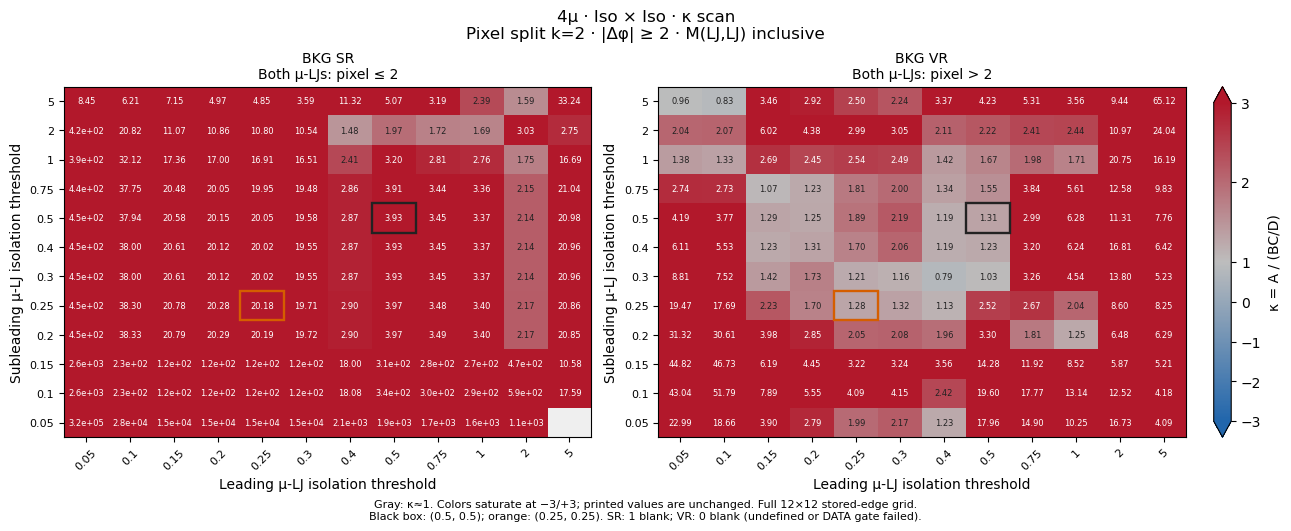

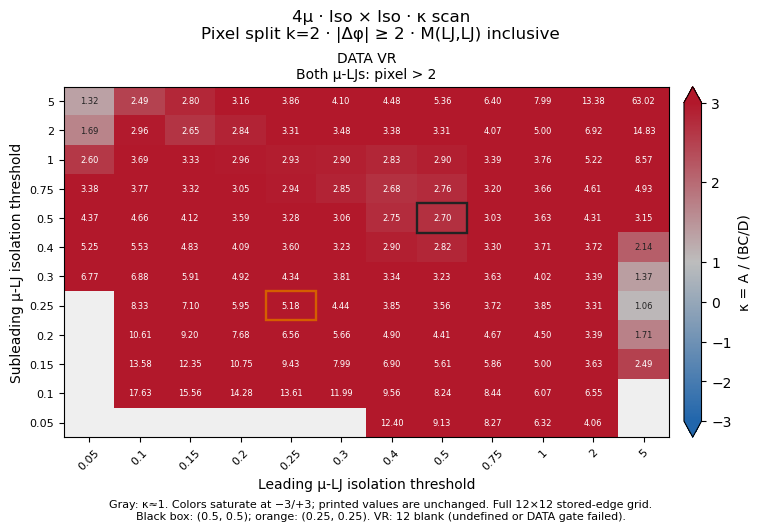

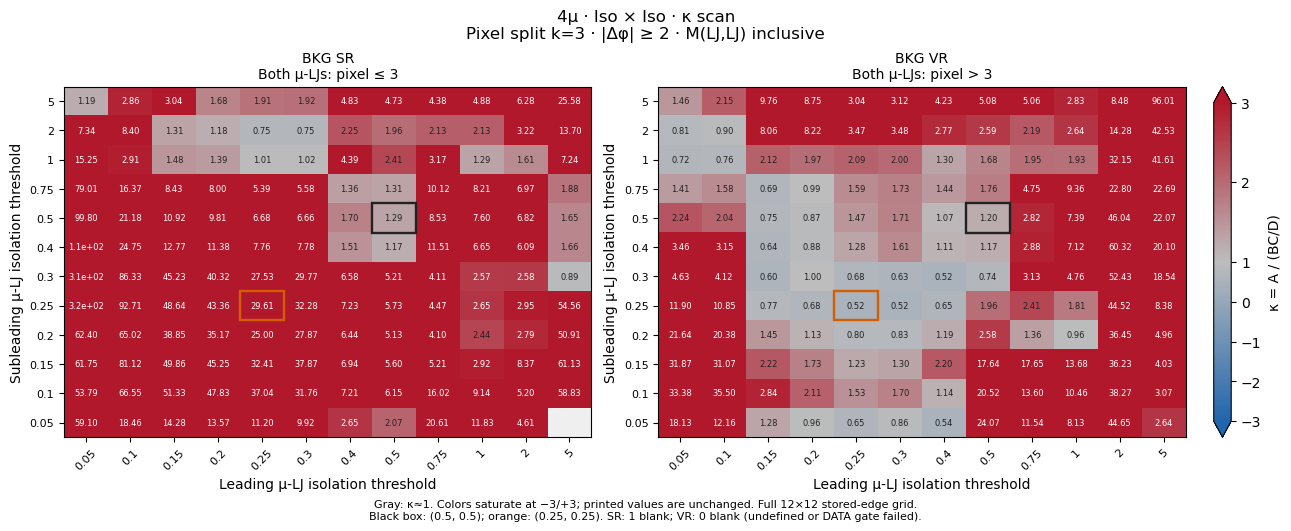

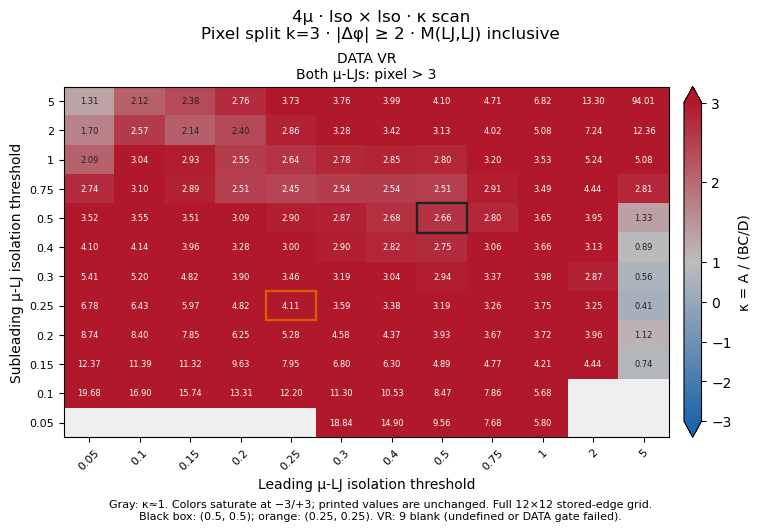

In [8]:
plot_scan_atlas(closure_grid)

## 6. Correlations and 2D distributions in the reference format

Correlation plots report ρ and Neff in **All/A/B/C/D columns**. They distinguish total BKG, individual background components in SR/VR, and permitted DATA VR.
The calculation uses weighted Pearson correlation at the centers of the plane's regular bins, excluding flow bins. Regions with negative bins or undefined variance remain N/A.
Both the existing full-plane table `corr_summary` and the new region-specific table `reference_corr_summary` are retained.

The 2D distributions use **two panels: BKG or DATA / the combined signal reference shape**. Isolation axes are linear up to 0.5 and symlog above that;
flow bins are merged into edge bins and marked with †. The red boundaries and the box highlighting A correspond to the `(0.5,0.5)` comparison point.
Only the signal panel sums the stored weights of all 180 hypotheses and then normalizes them to unit area. This figure is for shape comparison and is separate from the calculations of yields, S/B, and the DATA gate for individual hypotheses.
DATA correlations and distributions for each profile are displayed only if the comparison point passes the gate.

κ uncertainties, Neff, pulls, signal metrics, and changes at neighboring WPs are retained in `closure_grid`.
A neighboring WP moves one stored boundary within the same profile; no significance of the difference is calculated by treating overlapping events as independent.


4μ: MJJ inclusive, |Δφ| ≥ 2; both μ-LJs: SR pixel ≤ 2, VR pixel > 2


,group,profile,context,rho,neff,status
0,QCD,pixel2,SR,0.172301,6.435702,LOW_STAT
1,QCD,pixel2,VR,0.308699,76.767526,OK
2,DY,pixel2,SR,NaN,1.000000,ZERO_AXIS_VARIANCE
3,DY,pixel2,VR,-0.043464,71.920482,OK
4,TTJets,pixel2,SR,NaN,1.000000,ZERO_AXIS_VARIANCE
5,TTJets,pixel2,VR,0.304693,47.000000,OK
6,Diboson,pixel2,SR,NaN,NaN,EMPTY_OR_NONPOSITIVE
7,Diboson,pixel2,VR,-0.215353,14.191721,OK
8,BKG,pixel2,SR,0.218950,8.081518,LOW_STAT
9,BKG,pixel2,VR,0.318362,82.330247,OK


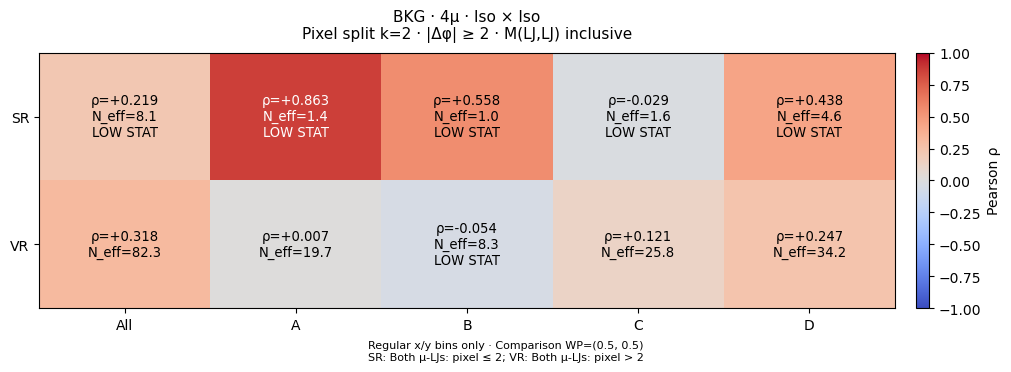

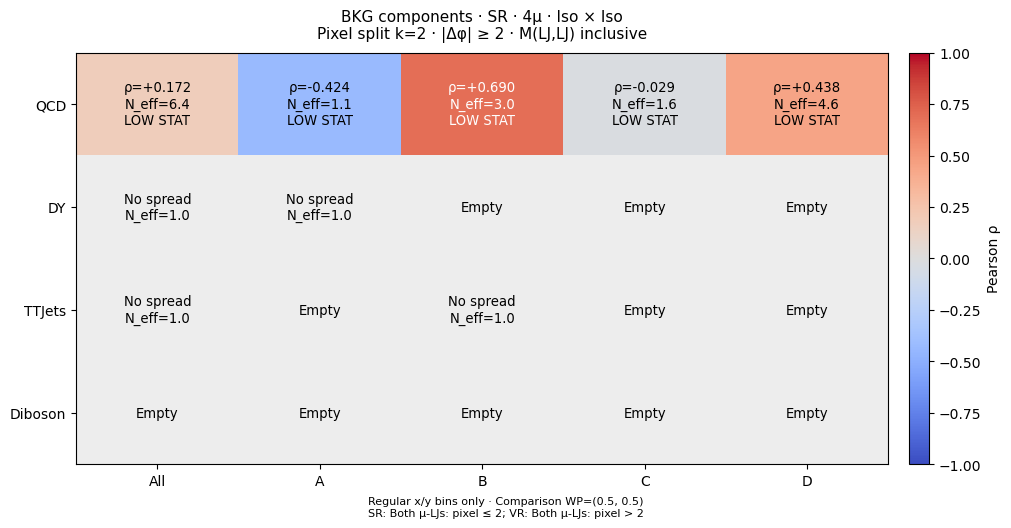

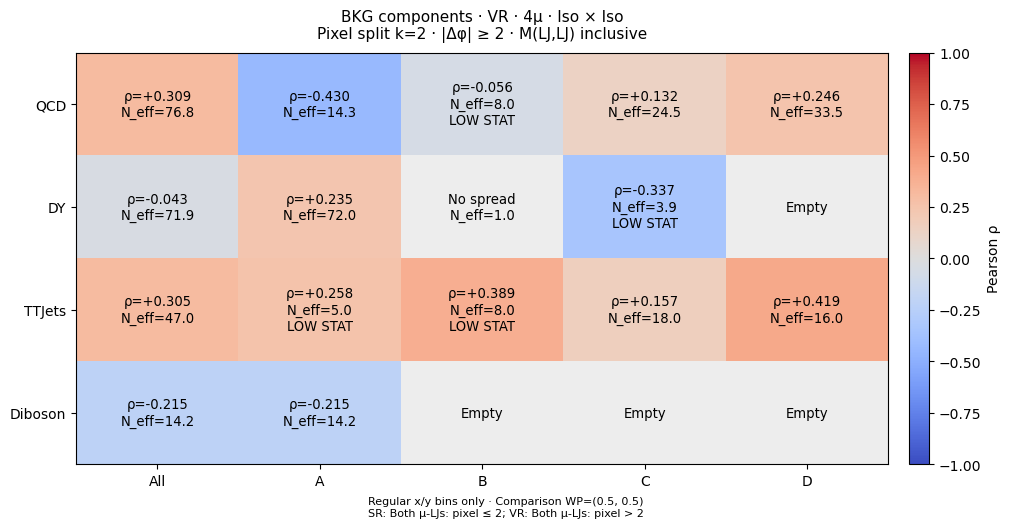

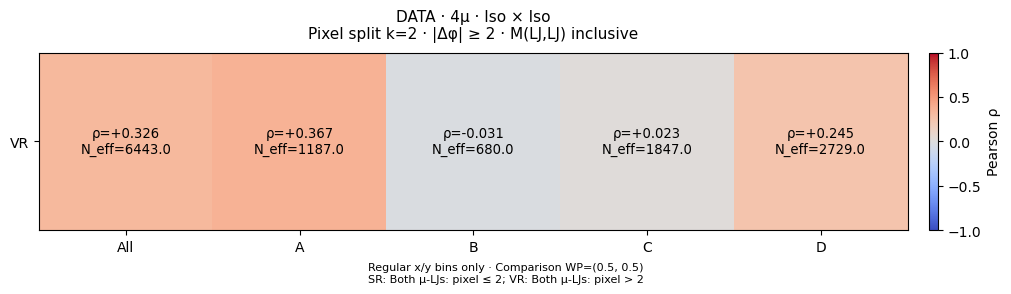

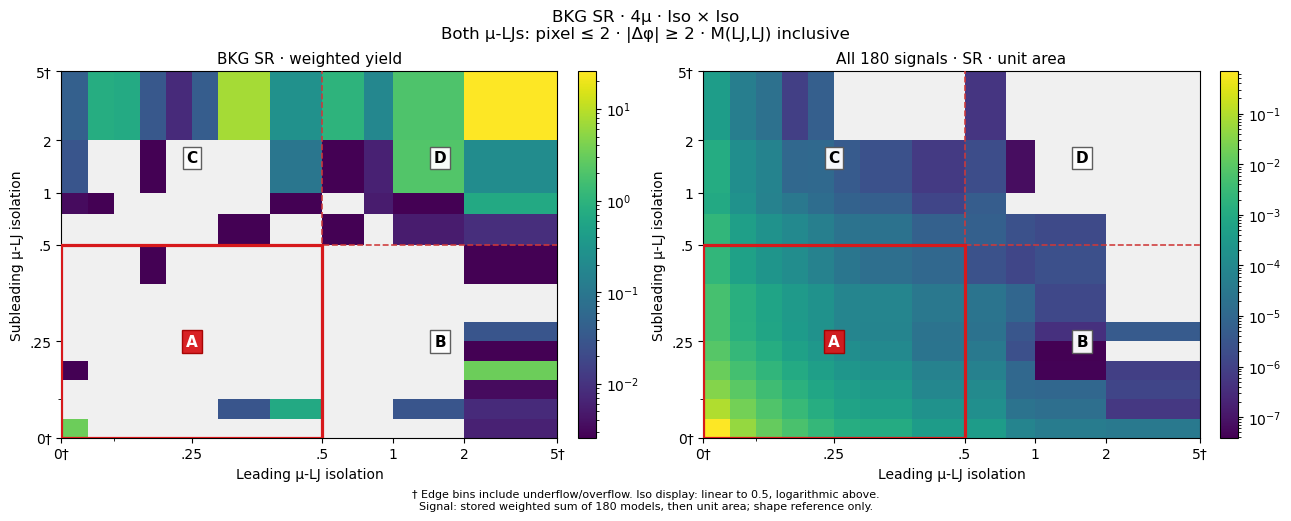

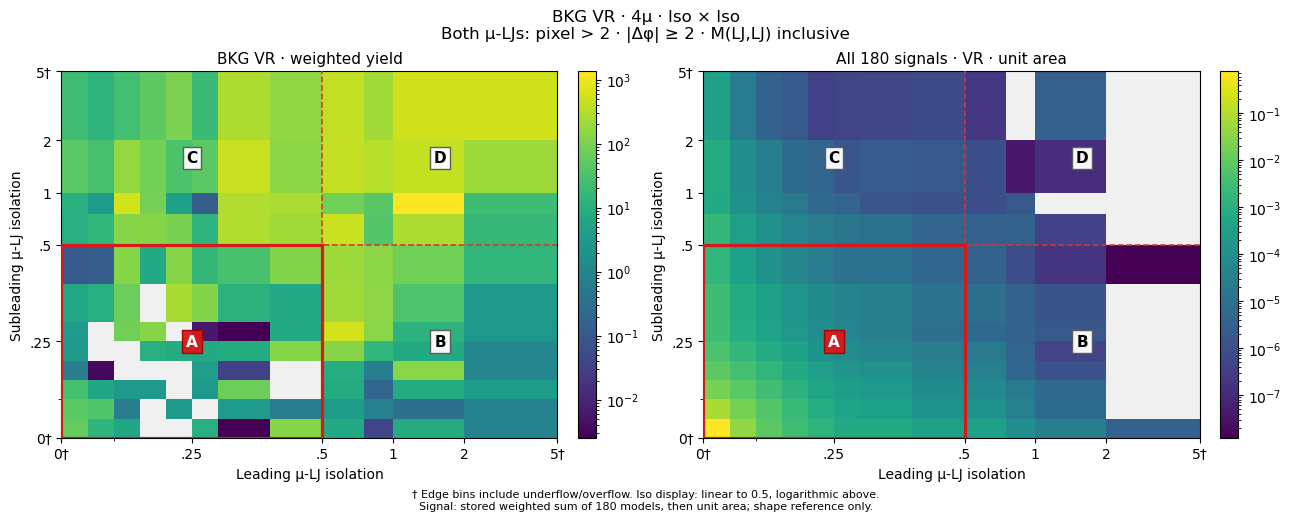

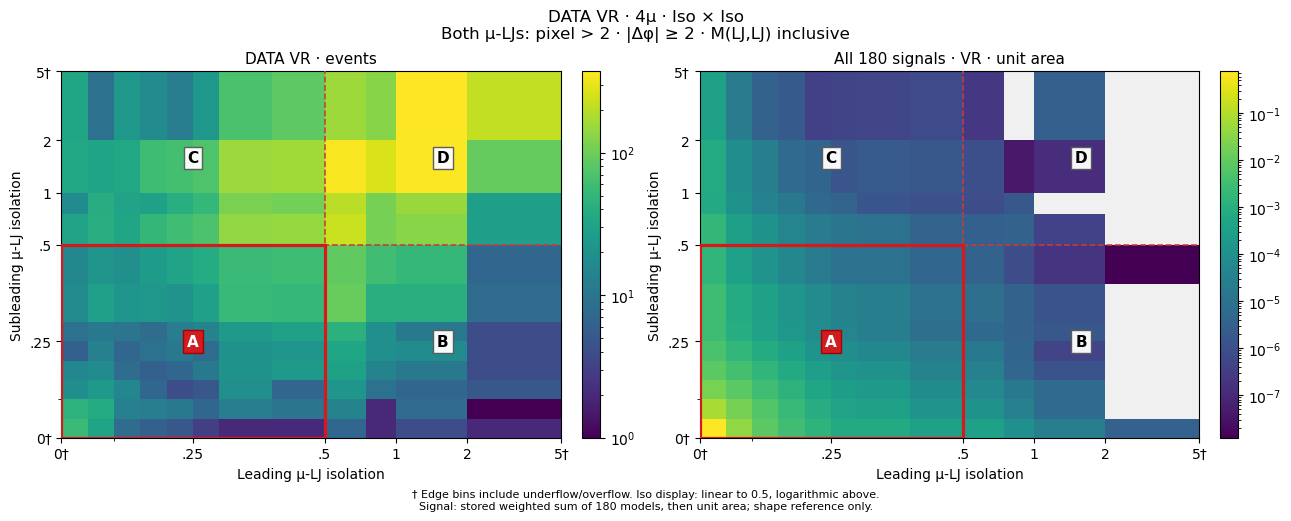

4μ: MJJ inclusive, |Δφ| ≥ 2; both μ-LJs: SR pixel ≤ 3, VR pixel > 3


,group,profile,context,rho,neff,status
0,QCD,pixel3,SR,0.152232,18.480024,OK
1,QCD,pixel3,VR,0.338870,46.257446,OK
2,DY,pixel3,SR,0.381571,12.000000,OK
3,DY,pixel3,VR,-0.126022,32.024763,OK
4,TTJets,pixel3,SR,-1.000000,2.000000,LOW_STAT
5,TTJets,pixel3,VR,0.393040,35.000000,OK
6,Diboson,pixel3,SR,NaN,1.788781,ZERO_AXIS_VARIANCE
7,Diboson,pixel3,VR,-0.248445,6.996462,LOW_STAT
8,BKG,pixel3,SR,0.192130,20.537506,OK
9,BKG,pixel3,VR,0.341320,48.753912,OK


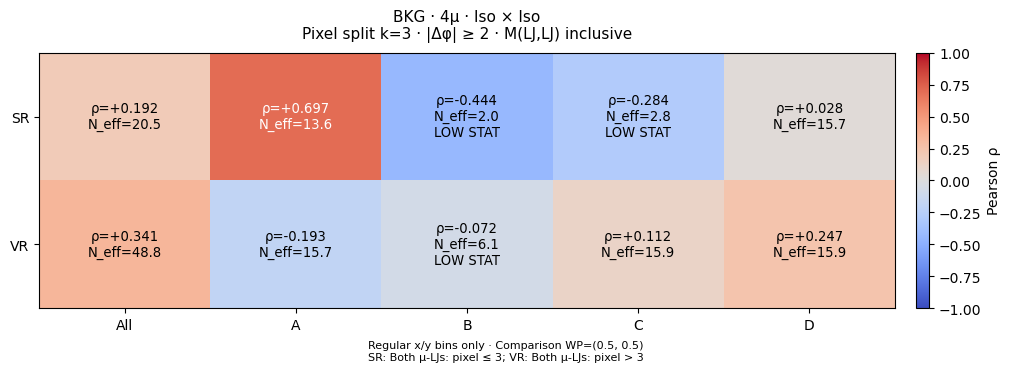

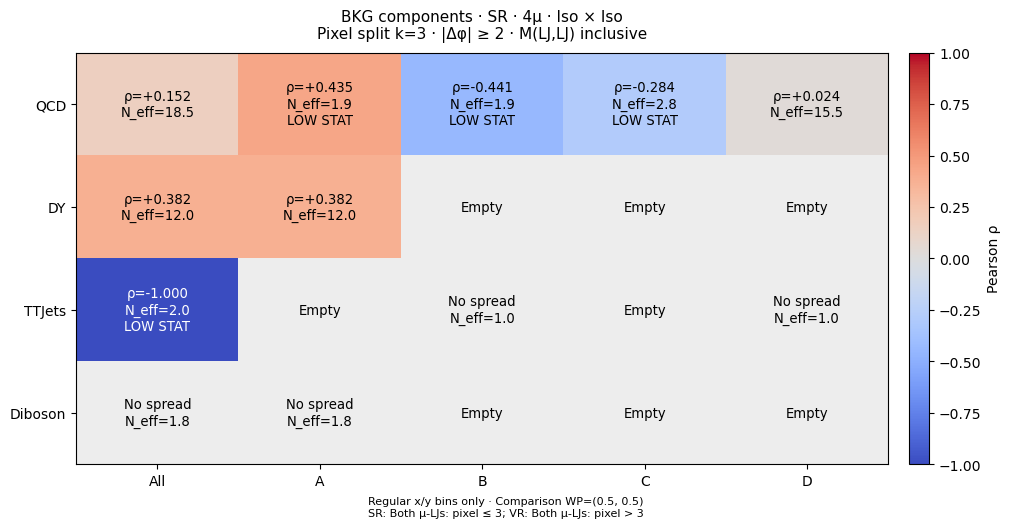

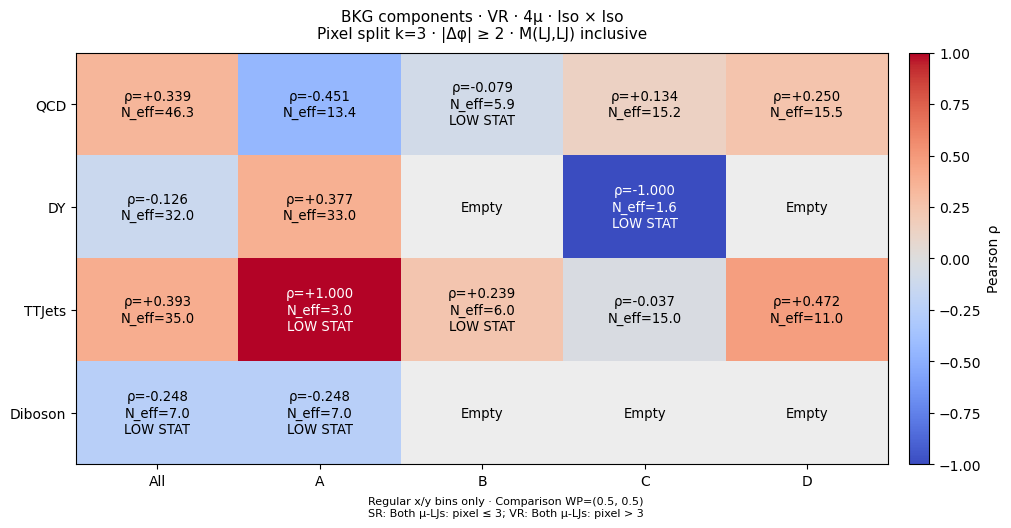

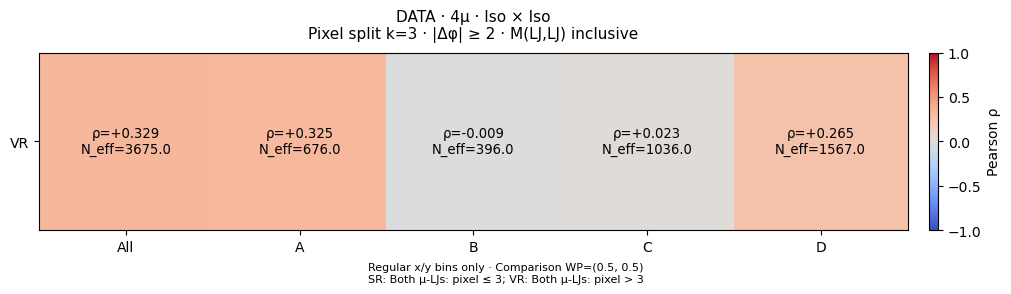

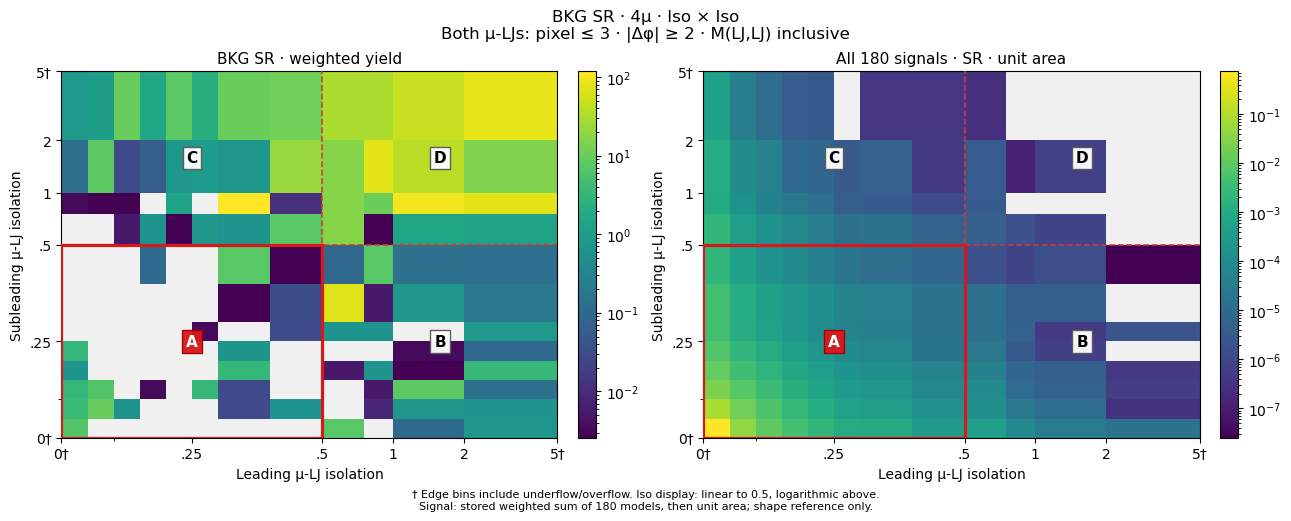

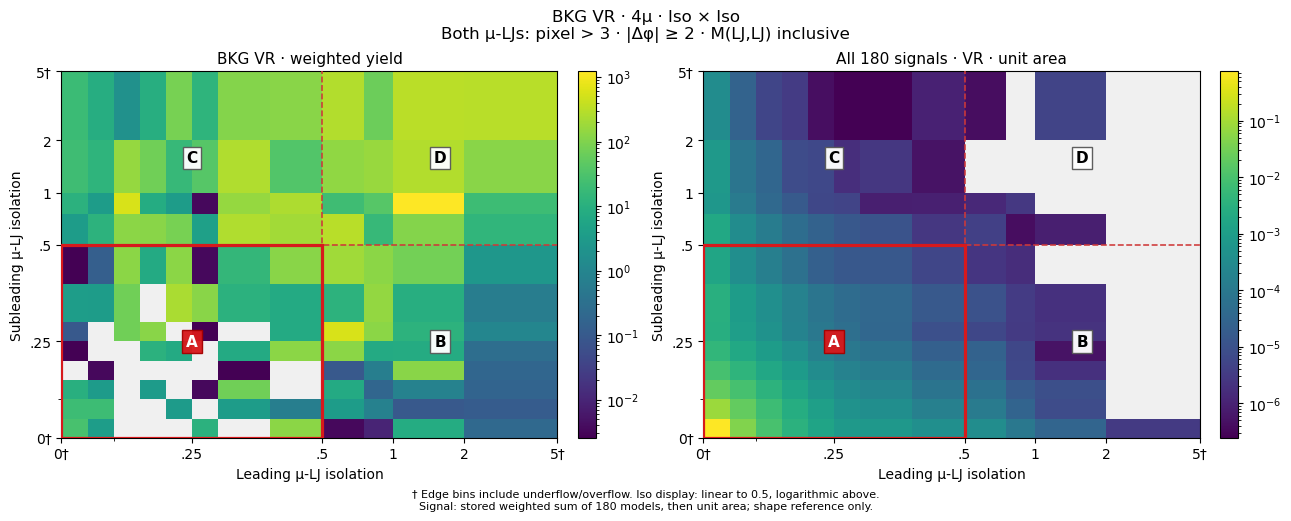

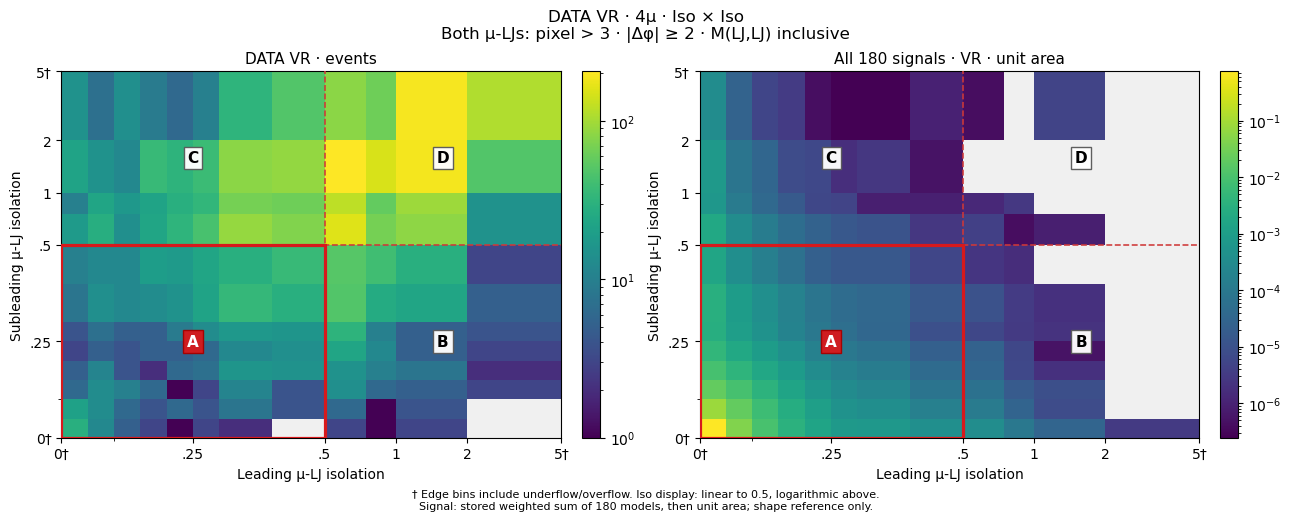

In [9]:
correlation_tables, reference_correlation_tables = [], []
for config in profiles:
    profile = config["profile"]
    print(profile_description(profile))
    corr = correlation_table(planes, profile, reference_gate(closure_grid, profile))
    correlation_tables.append(corr)
    display(corr)
    reference_correlation_tables.append(plot_correlations(planes, closure_grid, profile))
    plot_distributions(planes, closure_grid, profile, signal_names)
corr_summary = pd.concat(correlation_tables, ignore_index=True)
reference_corr_summary = pd.concat(reference_correlation_tables, ignore_index=True)

## 7. 1D closure in the loose reference format

When scanning one isolation axis, **the ABCD boundary on the other axis is fixed at 0.5**. This is not an event preselection; pass/fail events on both axes are retained.
No mass cut, |Δφ|≥2, and the displacement profile are maintained.

**BKG SR / BKG VR / DATA VR are plotted in separate figures**. Each figure has three vertically stacked panels and linear axes, as in the reference.
Top: observed A (blue) and the BC/D prediction (orange). Middle: κ±uncertainty (black). Bottom: individual prompt/displaced S/B_MC (purple) and leakage (orange, right percentage axis).
Dashed and solid signal lines correspond to prompt and displaced hypotheses, respectively; the red vertical dashed line marks the loose comparison point.
Every DATA line uses the same gate at each moving boundary. The denominators of the signal metrics in the bottom panel use MC.
The dashed 15% leakage line is a diagnostic guide from the reference; leakage is a different quantity from the 10% fraction condition in the DATA gate.

`CLOSURE_YLIM=None` displays all finite κ values and both ends of their error bars. A fixed range displays the counts of points and error bars outside that range.
All original numerical values and low-statistics statuses are retained in `one_d_scan`.


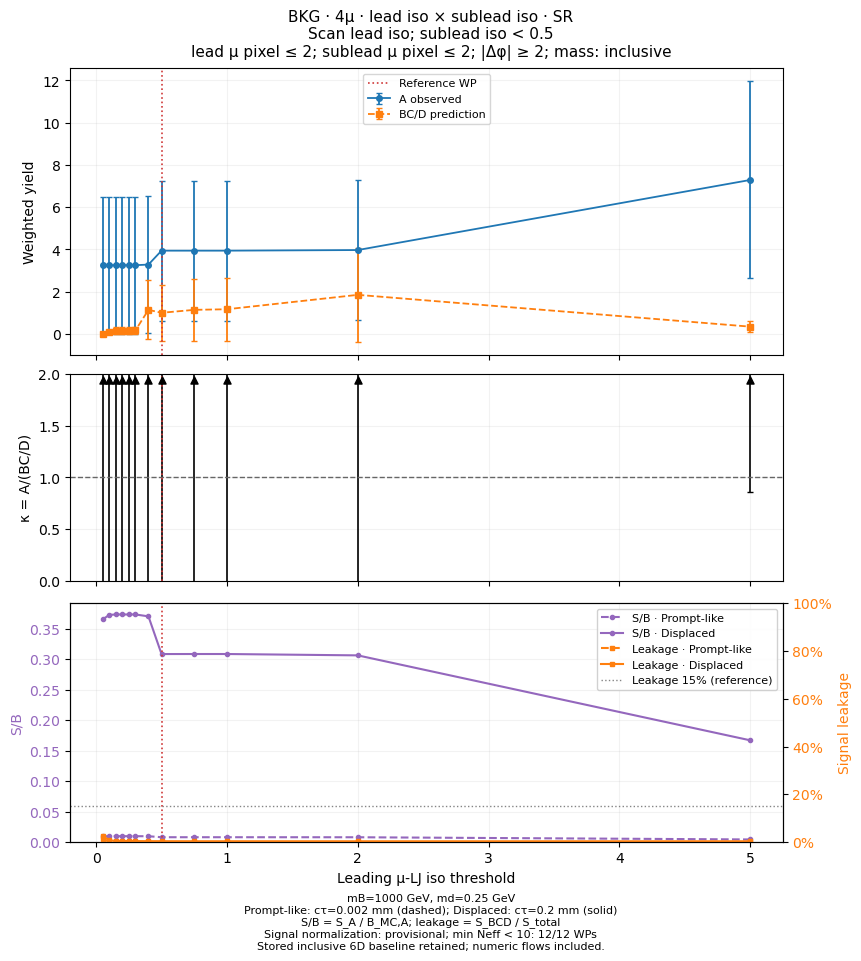

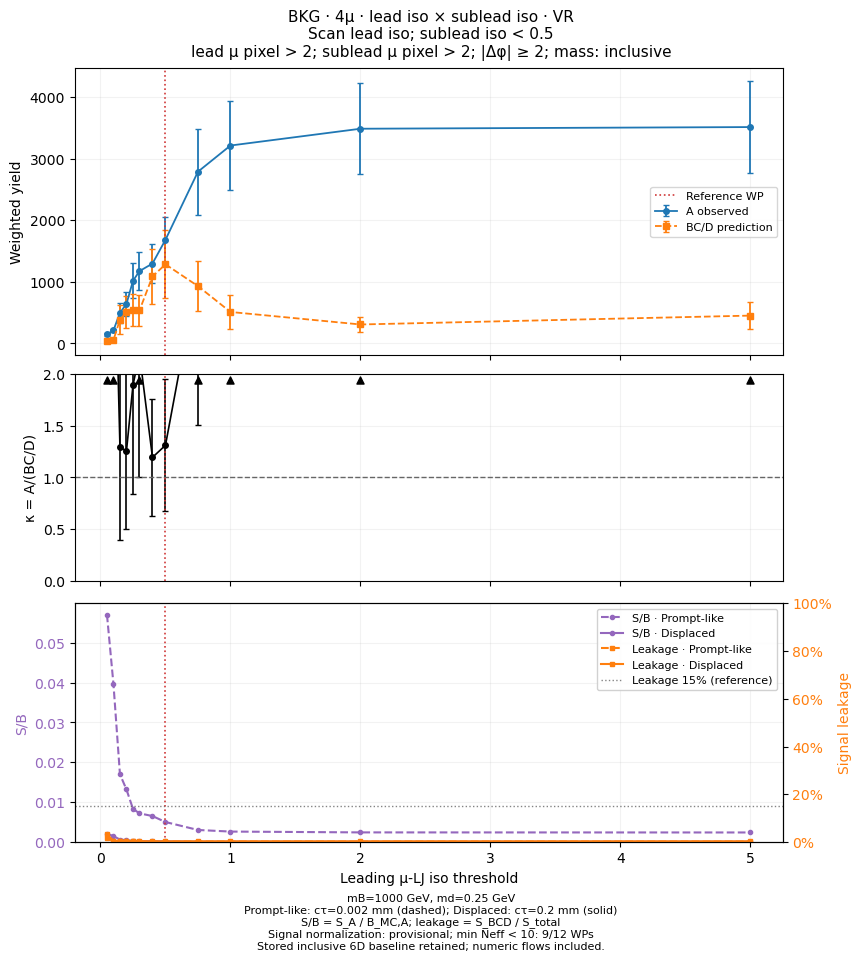

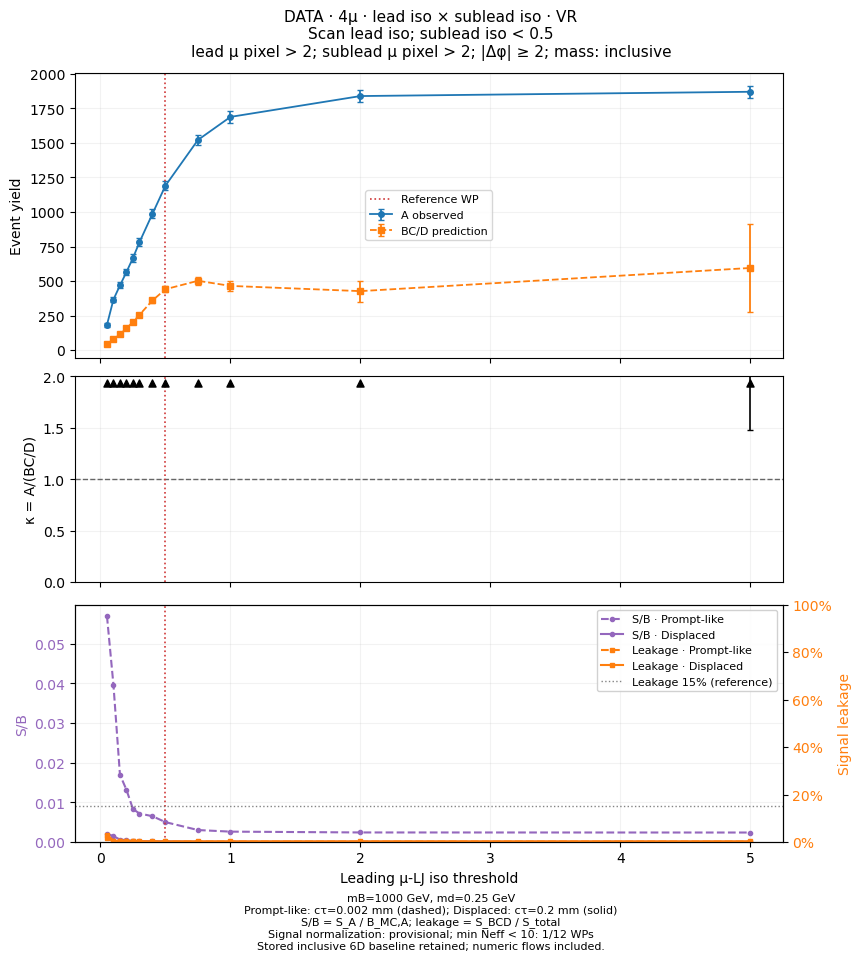

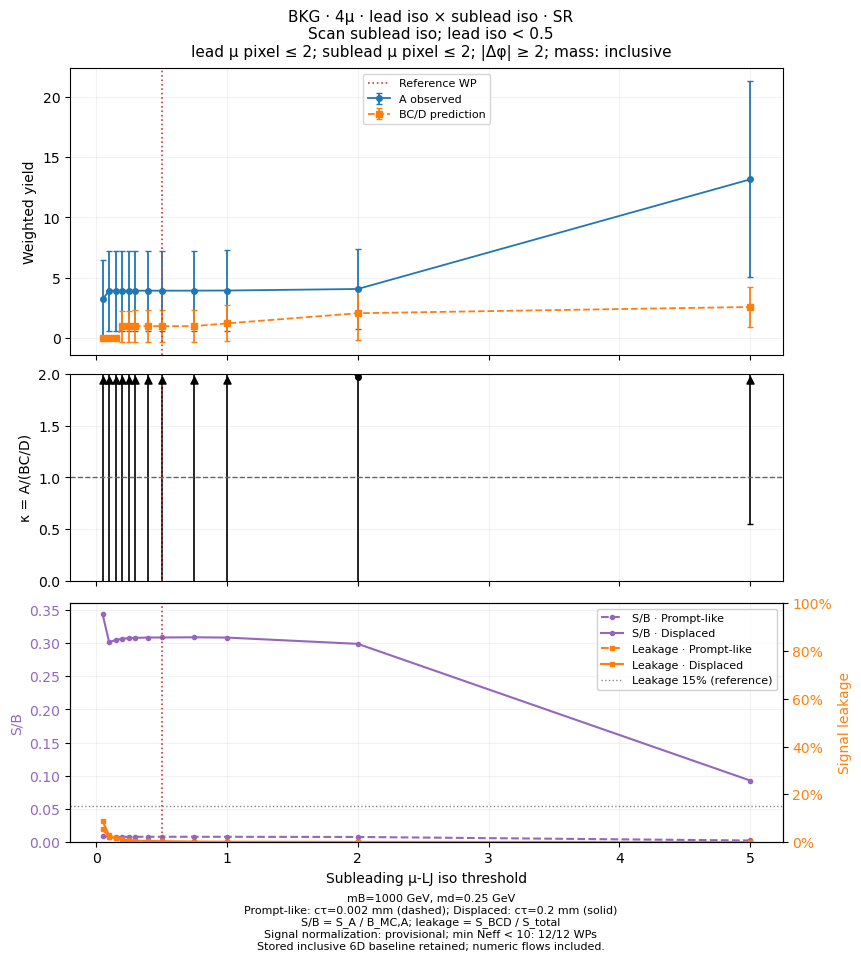

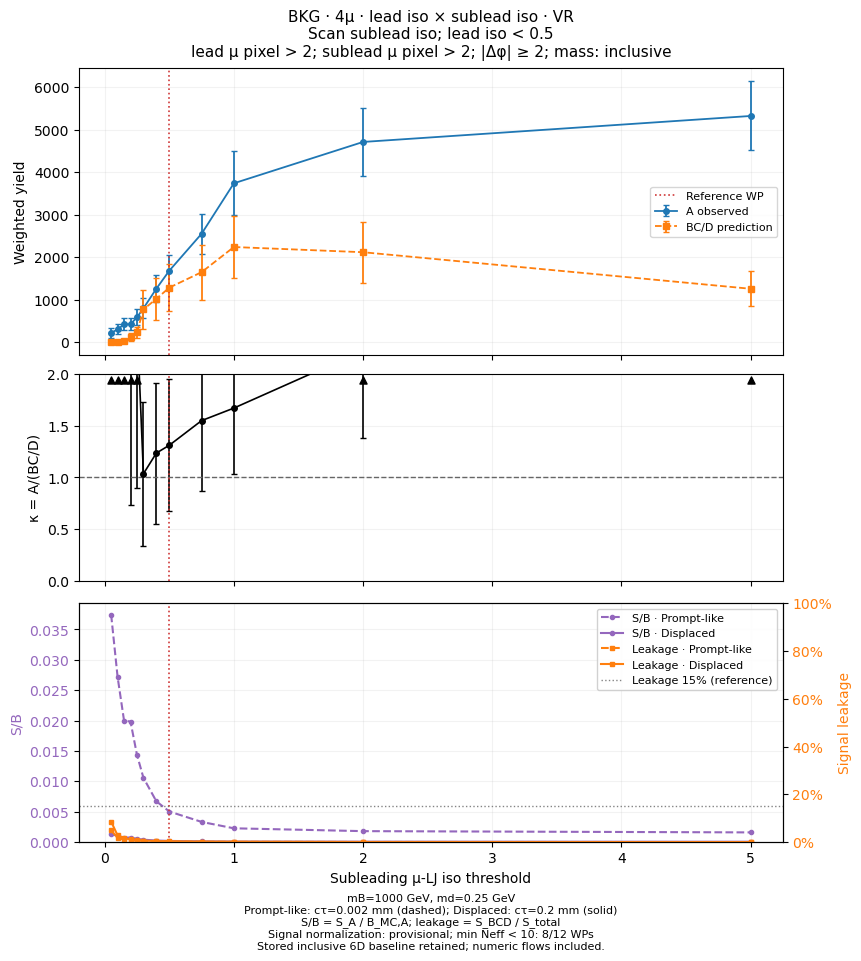

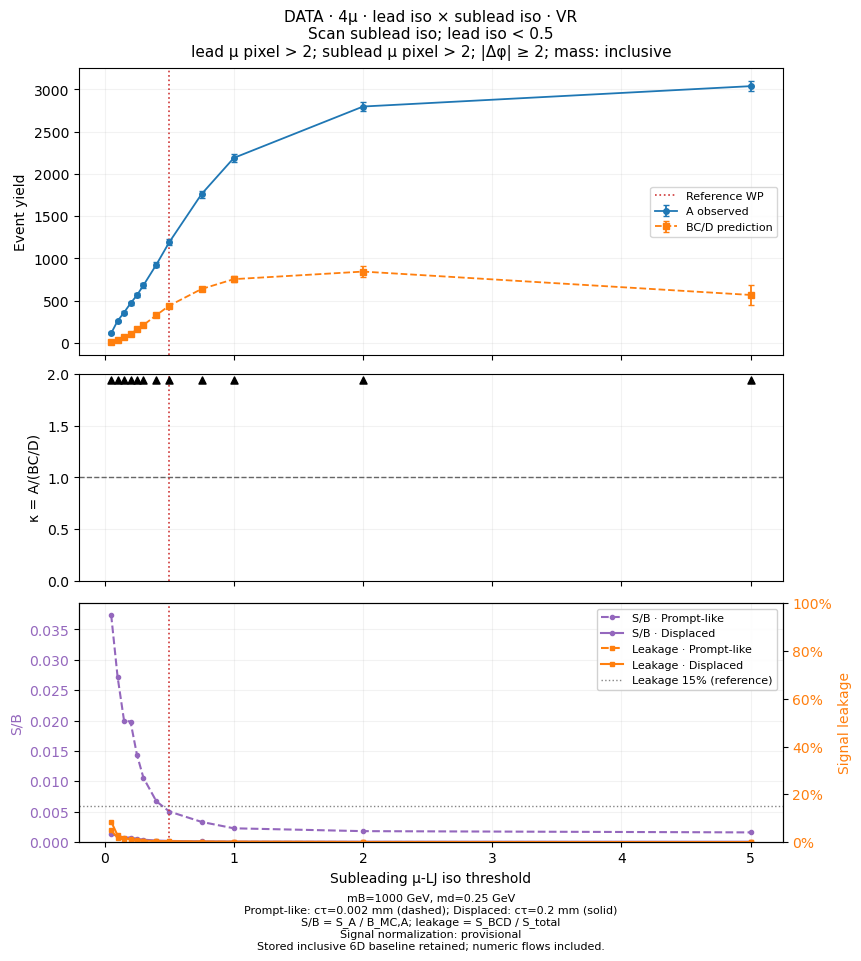

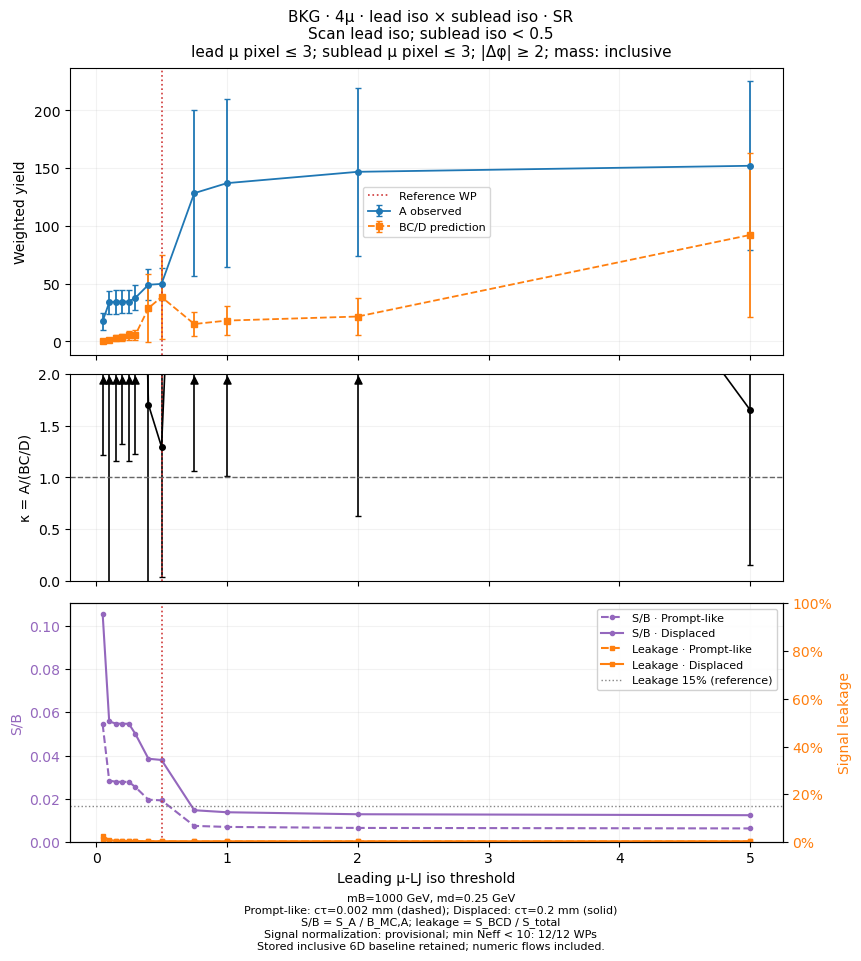

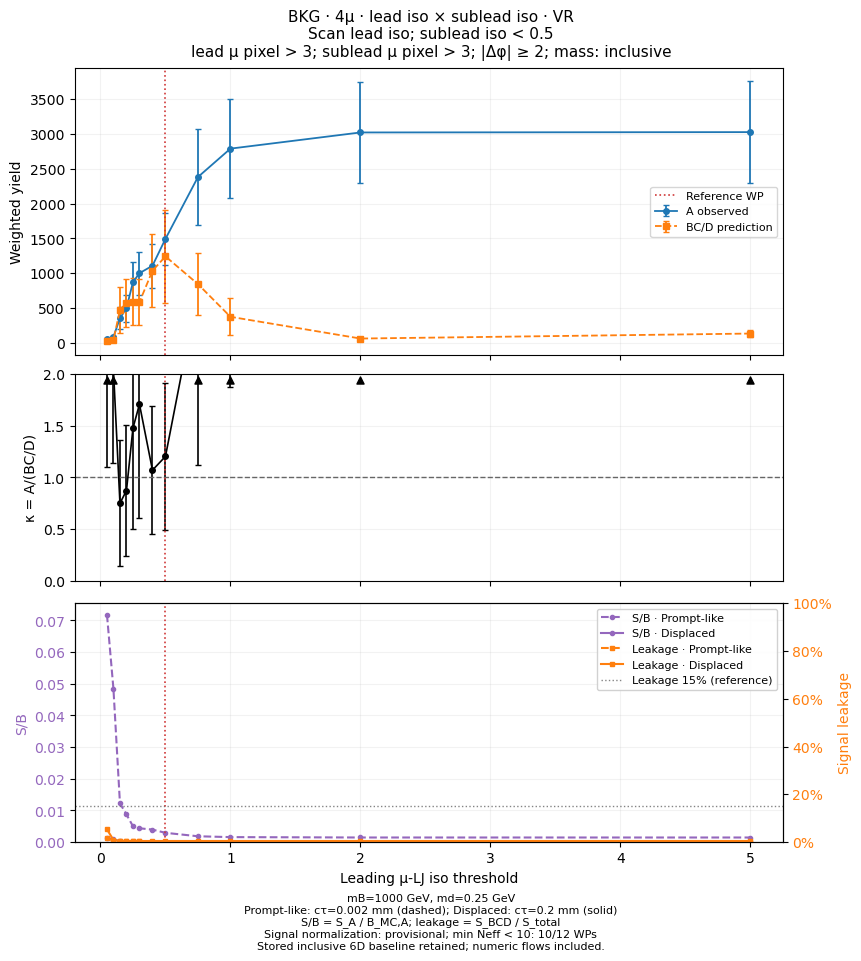

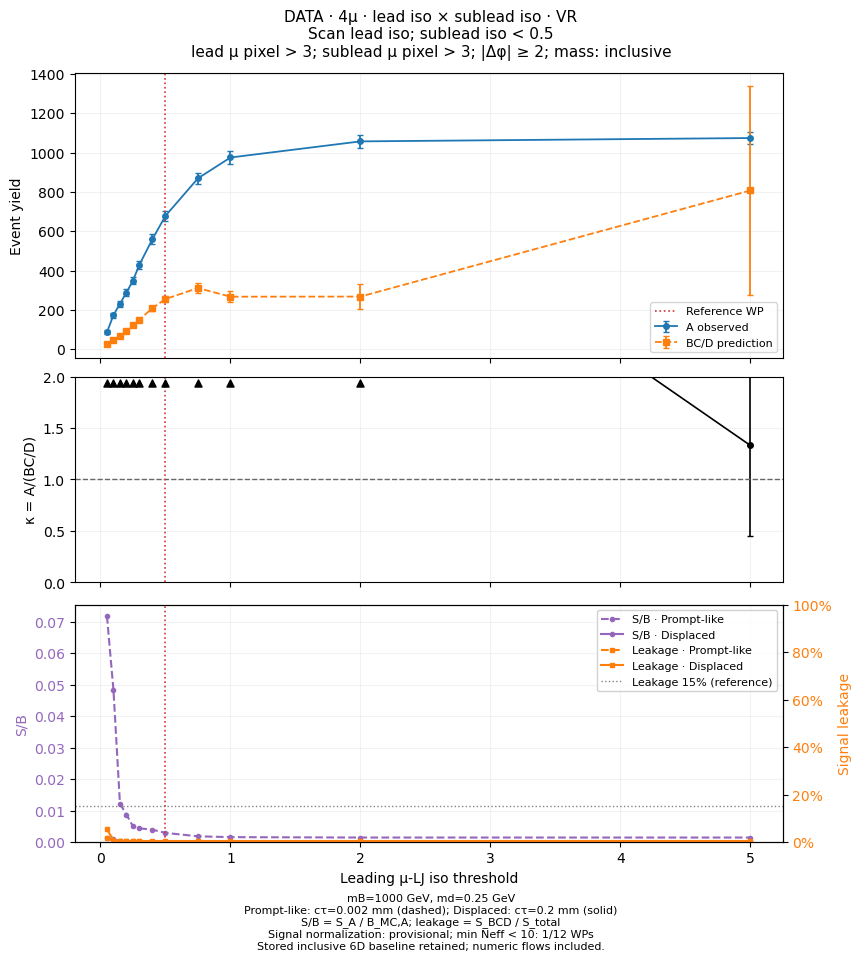

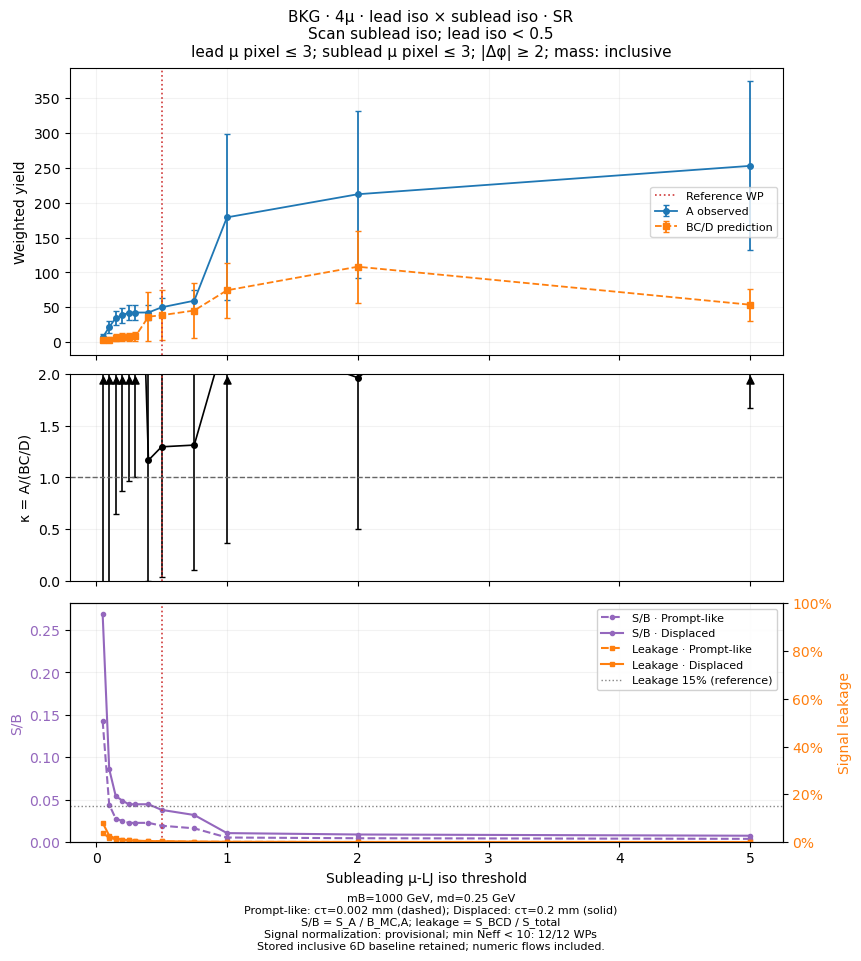

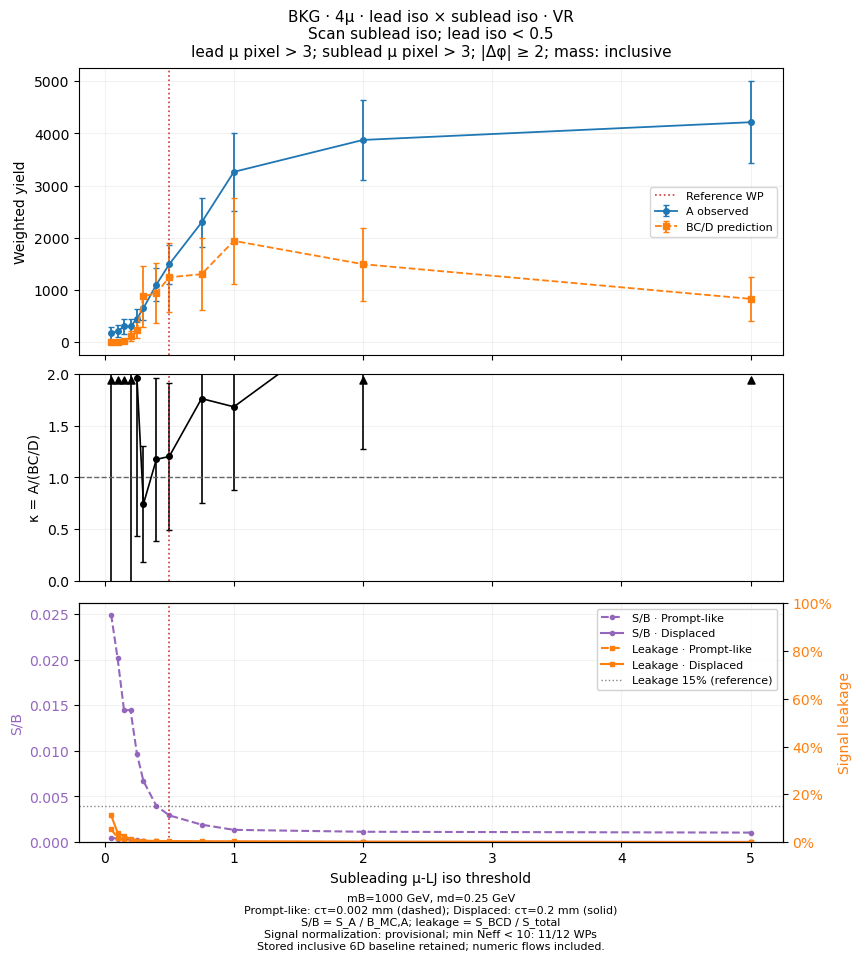

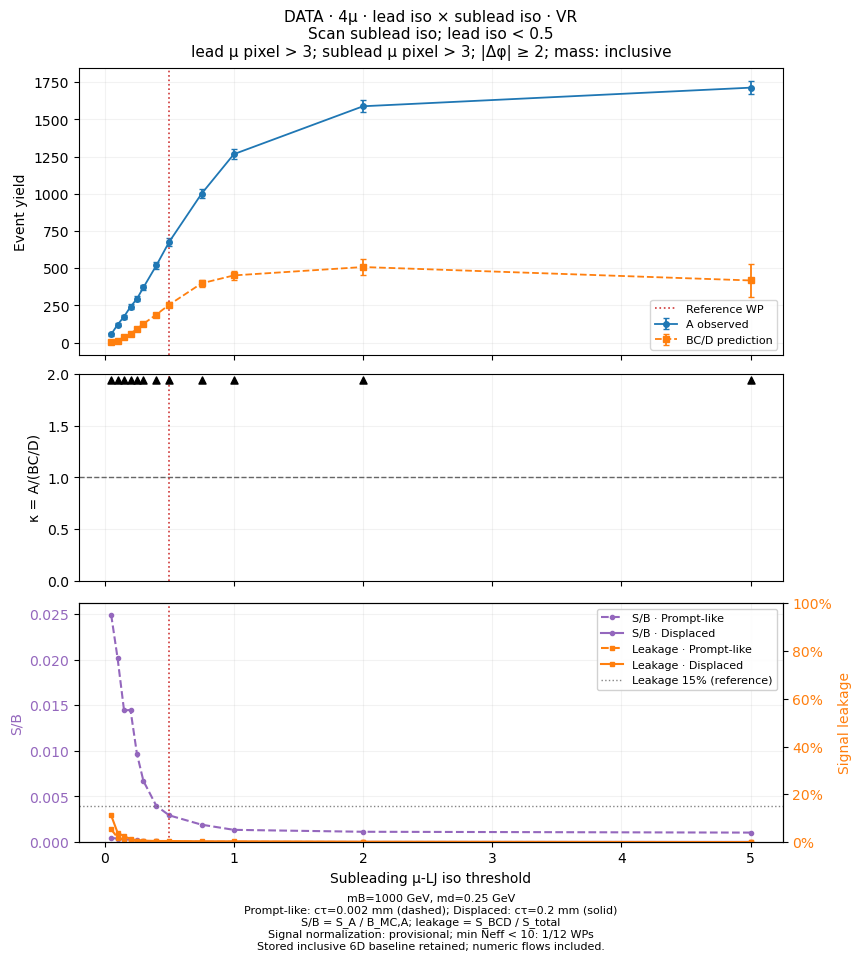

,profile,tx,ty,gate_passed,gate_reason,mc_SR_kappa,mc_SR_kappa_error,mc_SR_min_neff,mc_VR_kappa,mc_VR_kappa_error,mc_VR_min_neff,data_VR_kappa,data_VR_kappa_error,data_VR_min_neff
7,pixel2,0.05,0.50,True,,446.616367,650.368413,1.003167,4.187951,1.650427,14.432978,4.369234,0.535026,115.0
19,pixel2,0.10,0.50,True,,37.944828,58.926636,1.003167,3.765281,1.312351,19.937423,4.658496,0.412324,237.0
31,pixel2,0.15,0.50,True,,20.584509,30.373452,1.003167,1.293134,0.897296,3.236571,4.116902,0.315325,358.0
43,pixel2,0.20,0.50,True,,20.152900,29.630379,1.004753,1.253006,0.750446,5.363493,3.594988,0.246891,513.0
55,pixel2,0.25,0.50,True,,20.052008,29.459753,1.004753,1.887986,1.051746,7.133384,3.280105,0.207978,667.0
67,pixel2,0.30,0.50,True,,19.582620,28.672045,1.004753,2.193841,1.193379,7.872084,3.063828,0.182727,781.0
79,pixel2,0.40,0.50,True,,2.873689,4.519655,1.022758,1.192975,0.567070,11.011223,2.748491,0.154447,888.0
84,pixel2,0.50,0.05,True,,1879.736309,2770.700815,1.001583,17.955798,15.628478,2.499144,9.134868,2.520527,15.0
85,pixel2,0.50,0.10,True,,338.822554,470.847832,1.412155,19.596031,13.236077,3.970380,8.236730,1.414310,40.0
86,pixel2,0.50,0.15,True,,314.010089,429.202047,1.412155,14.284815,7.798800,7.323672,5.612669,0.698491,83.0


In [10]:
one_d_scan = closure_grid.loc[
    np.logical_or.reduce([np.isclose(closure_grid.tx, fixed) | np.isclose(closure_grid.ty, fixed)
                          for fixed in ONE_D_FIXED])].copy()
for config in profiles:
    plot_one_dimensional(closure_grid, config["profile"])
display(one_d_scan[["profile", "tx", "ty", "gate_passed", "gate_reason",
                    "mc_SR_kappa", "mc_SR_kappa_error", "mc_SR_min_neff",
                    "mc_VR_kappa", "mc_VR_kappa_error", "mc_VR_min_neff",
                    "data_VR_kappa", "data_VR_kappa_error", "data_VR_min_neff"]])

## 8. Individual signals and numerical SR/VR comparisons

All 180 hypotheses are retained separately at `(0.25,0.25)` and the loose `(0.5,0.5)` point. Signal yields and metrics are calculated individually for each hypothesis. The combined shape shown earlier is not used for these values.
`signal_points` provides each signal's S/B_MC, leakage, prediction inflation, and A efficiency relative to the inclusive yield; only the two gate reference hypotheses are displayed below.
The uncertainty on the SR/VR κ ratio uses first-order propagation only under the condition that the two displacement regions are mutually exclusive.
The pixel≤2 and ≤3 results overlap, so no independent uncertainty on their difference or combined significance is calculated.


In [11]:
signal_points = signal_reference_table(planes, profiles, signal_names, signal_inclusive,
                                       working_points=((.25, .25), (.5, .5)))
display(signal_points.loc[signal_points["sample"].isin(SIGNAL_REFERENCES[TOPOLOGY].values()),
                          ["sample", "profile", "context", "tx", "ty", "signal_A", "eff_A",
                           "leakage", "leakage_error", "s_over_b", "prediction_inflation", "signal_status"]])
transfer_summary = closure_grid[["profile", "tx", "ty", "mc_SR_kappa", "mc_SR_kappa_error",
                                 "mc_VR_kappa", "mc_VR_kappa_error", "mc_SR_min_neff", "mc_VR_min_neff"]].copy()
sr, vr = transfer_summary.mc_SR_kappa, transfer_summary.mc_VR_kappa
good = np.isfinite(sr) & np.isfinite(vr) & (sr > 0) & (vr > 0)
transfer_summary["kappa_SR_over_VR"] = np.where(good, sr/vr, np.nan)
transfer_summary["ratio_error"] = np.where(good, np.sqrt(
    (transfer_summary.mc_SR_kappa_error/vr)**2 + (sr*transfer_summary.mc_VR_kappa_error/vr**2)**2), np.nan)
display(transfer_summary.loc[np.isclose(transfer_summary.tx, .5) & np.isclose(transfer_summary.ty, .5)])

,sample,profile,context,tx,ty,signal_A,eff_A,leakage,leakage_error,s_over_b,prediction_inflation,signal_status
180,4Mu_1000GeV_0p25GeV_0p002mm,pixel2,SR,0.25,0.25,0.031467,0.003302,0.000000,0.000000,0.009673,0.000000e+00,LOW_STAT
181,4Mu_1000GeV_0p25GeV_0p002mm,pixel2,SR,0.50,0.50,0.031467,0.003302,0.000000,0.000000,0.007979,0.000000e+00,LOW_STAT
184,4Mu_1000GeV_0p25GeV_0p2mm,pixel2,SR,0.25,0.25,1.211324,0.425481,0.008281,0.000934,0.372351,5.868311e-03,LOW_STAT
185,4Mu_1000GeV_0p25GeV_0p2mm,pixel2,SR,0.50,0.50,1.216900,0.427439,0.003716,0.000627,0.308572,5.502018e-04,LOW_STAT
540,4Mu_1000GeV_0p25GeV_0p002mm,pixel2,VR,0.25,0.25,8.425101,0.884214,0.006075,0.000229,0.036938,2.607833e-05,LOW_STAT
541,4Mu_1000GeV_0p25GeV_0p002mm,pixel2,VR,0.50,0.50,8.458328,0.887702,0.002155,0.000136,0.005031,5.352461e-06,LOW_STAT
544,4Mu_1000GeV_0p25GeV_0p2mm,pixel2,VR,0.25,0.25,0.315896,0.110959,0.008143,0.001813,0.001385,1.096636e-06,LOW_STAT
545,4Mu_1000GeV_0p25GeV_0p2mm,pixel2,VR,0.50,0.50,0.317452,0.111506,0.003257,0.001150,0.000189,2.823185e-07,LOW_STAT
900,4Mu_1000GeV_0p25GeV_0p002mm,pixel3,SR,0.25,0.25,0.956473,0.100382,0.007006,0.000728,0.027800,2.119619e-04,LOW_STAT
901,4Mu_1000GeV_0p25GeV_0p002mm,pixel3,SR,0.50,0.50,0.960654,0.100821,0.002665,0.000450,0.019301,1.311505e-05,LOW_STAT


,profile,tx,ty,mc_SR_kappa,mc_SR_kappa_error,mc_VR_kappa,mc_VR_kappa_error,mc_SR_min_neff,mc_VR_min_neff,kappa_SR_over_VR,ratio_error
91,pixel2,0.5,0.5,3.928021,6.108735,1.309608,0.636093,1.049635,8.300235,2.999386,4.886759
235,pixel3,0.5,0.5,1.294882,1.261225,1.201921,0.710162,2.071234,6.096730,1.077344,1.227322


## 9. Additional plots for review — proposed formats

**A. DATA access and statistical status map:** Colors distinguish points blocked by the MC gate, undefined κ, low statistics, and points satisfying the Neff criterion. Satisfying the statistical criterion does not imply closure.

**B. Neff–κ uncertainty scatter plot:** Compares the minimum Neff and κ uncertainty across all WPs. The star marks the loose `(0.5,0.5)` comparison point. Only finite positive values are displayed on logarithmic axes.

**C. 4μ ≤2/≤3 comparison (shown only in 02):** Overlays the two DATA VR profiles on the same 1D κ plot. The isolation boundary on the other axis is 0.5, and the displayed range is ≤1.0. The original full scan is retained in the earlier section.
The two VR samples overlap, so the significance of their difference is not evaluated assuming independent samples.

These figures are for reviewing display formats. They do not add or change selections, the gate, or criteria for choosing a WP.


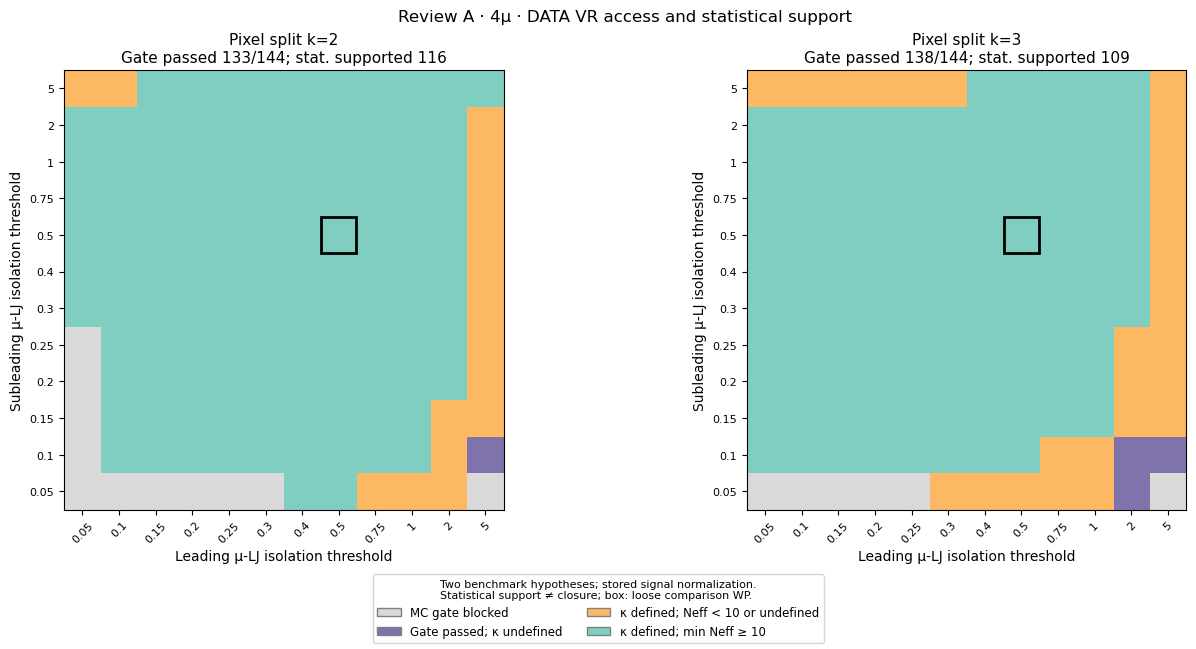

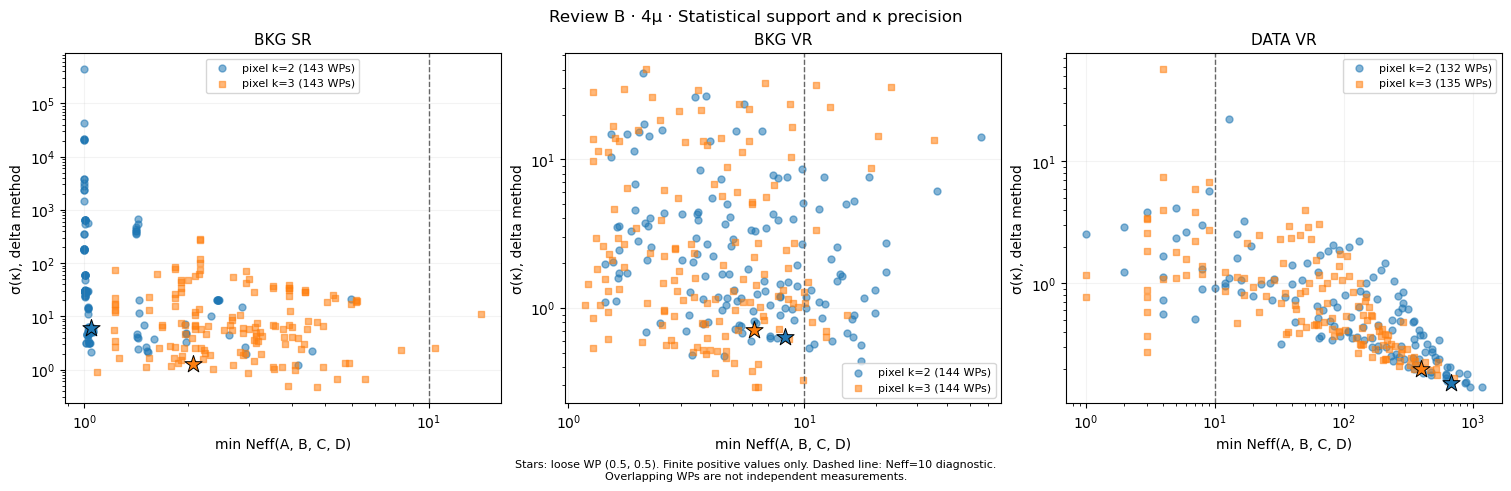

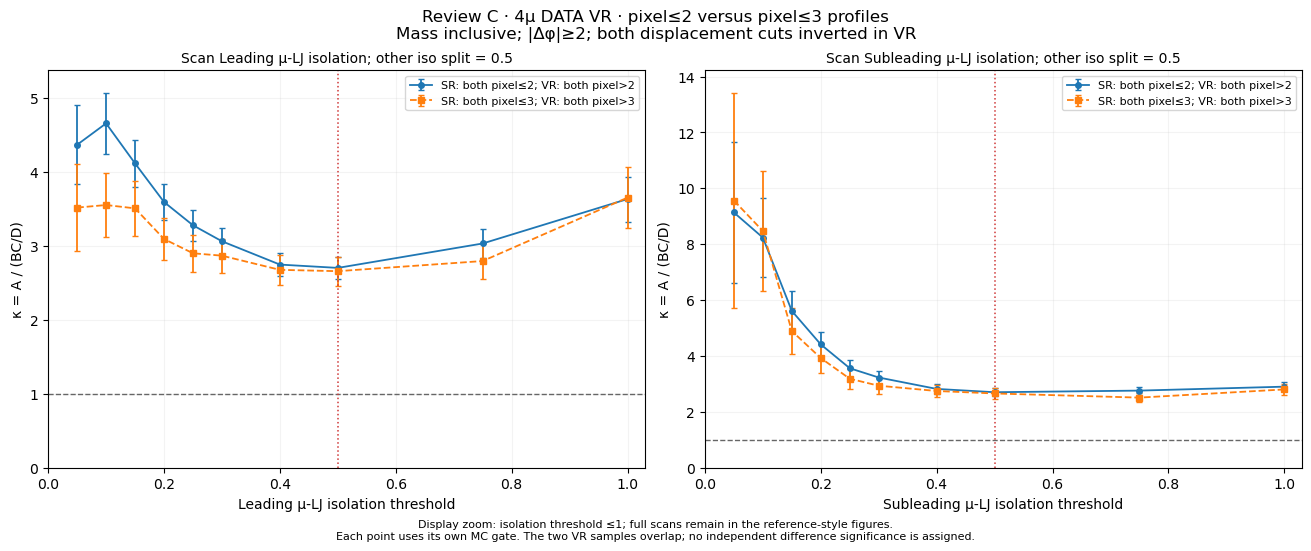

Review PNG/PDF files: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/Plot_style_review


In [12]:
review_access = plot_data_access_review(closure_grid)
plot_precision_review(closure_grid)
plot_displacement_review(closure_grid)
print("Review PNG/PDF files:", REVIEW_DIR if SAVE_REVIEW_FIGURES else "saving disabled")

## 10. Saving results and interpretation

Check valid κ values and statistical support in `profile_overview`, and review the basis for DATA access in `data_access_review`.
Interpret closure using `one_d_scan` and its uncertainties. Compatibility with κ=1 due to large uncertainties is distinct from a precise closure validation or proof of the SR background prediction.
An alternative WP is not selected automatically if the scan results are unsatisfactory. All settings, reasons for failure, and original numerical values are retained.

`EXPORT_TABLES=True` saves CSV files and a manifest. `SAVE_FIGURES=True` saves PNG/PDF files when the corresponding figure cells are executed.
DATA SR values and DATA values at points that fail the gate are absent from all tables, figures, and exports. Only VR projections for permitted profiles exist in memory.

`SAVE_REVIEW_FIGURES=True` saves only the review figures as PNG/PDF files in `Plot_style_review/`. Files with the same names are updated when rerun.


In [13]:
TABLES = dict(profile_overview=profile_overview, mc_inventory=mc_inventory,
              data_inventory=data_inventory, closure_grid=closure_grid,
              data_access_review=data_access_review, corr_summary=corr_summary,
              reference_corr_summary=reference_corr_summary, review_access=review_access,
              one_d_scan=one_d_scan, signal_points=signal_points, transfer_summary=transfer_summary)
assert len(closure_grid) == len(profiles)*len(ISO_CUTS)**2
assert all(context == "VR" for group, profile, context in planes if group == "Data")
if EXPORT_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, table in TABLES.items():
        table.to_csv(OUTPUT_DIR / (name+".csv"), index=False)
    manifest = dict(campaign=CAMPAIGN, topology=TOPOLOGY, profiles=profiles,
                    iso_cuts=ISO_CUTS.tolist(), display_wp=DISPLAY_WP, one_d_fixed=ONE_D_FIXED,
                    signal_references=SIGNAL_REFERENCES[TOPOLOGY], signal_scale=SIGNAL_SCALE,
                    signal_normalization_verified=SIGNAL_NORMALIZATION_VERIFIED,
                    all_signals=LOAD_ALL_SIGNALS, data_policy="VR only; per-WP two-reference MC gate",
                    maximum_signal_fraction=MAX_SIGNAL_FRACTION,
                    created_utc=datetime.now(timezone.utc).isoformat())
    (OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
    print("Saved:", OUTPUT_DIR)
else:
    print("CSV/manifest saving is disabled. All results are available in TABLES.")
print("Complete: no automatic final WP selection; all DATA SR remains blinded.")

CSV/manifest saving is disabled. All results are available in TABLES.
Complete: no automatic final WP selection; all DATA SR remains blinded.
